# CFRM 521/421 Machine Learning for Finance
## Course Project Template

**Project Title:** Volatility Prediction of Microsoft Using Machine Learning

**Group Members:**  
- Jenny Fu (email: jennyfu1@uw.edu, Algorithm: Support Vector Regression)
- Emma Xu (email: zihanxu@uw.edu, Algorithm: Gradient Boosing)  
- Shawn Wen (email: ___, Algorithm: Neural Network with MLP)  
- Zihan Zhu (email: zihanzhu@uw.edu, Algorithm: Random Forest)   

**Date:**

<span style="color:red">
**Please remove the bullet points in each section as you proceed and feel free to adjust the structure and contents as needed.
</span>

# 1. Introduction

## 1.1 Problem Statement
- What is the goal of your project?
- Why is this problem important in finance?
- What financial decision, prediction, or classification task are you studying?

## 1.2 Related Literature
- Briefly summarize relevant papers or prior work.
- Explain how your project relates to existing studies.
- Cite all sources properly.

## 1.3 Contribution
- What does your project add beyond existing work?
- Is your contribution empirical comparison, replication with extensions, new data, or a new application?


# 2. Data Description

## 2.1 Data Source
- Describe the original source of the data.
- Include links, API names, or repository names if relevant.

## 2.2 Data Structure
- What does each row represent?
- What is the sampling frequency?
- How many observations are there?
- What time period does the data cover?

## 2.3 Target Variable
- Define the response variable clearly.

## 2.4 Features
- List and briefly describe the predictors.
- Give a few examples.

## 2.5 Data Cleaning and Preprocessing
- Missing values
- Outlier handling
- Scaling or normalization
- Feature engineering
- Train/validation/test split


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Reproducibility
np.random.seed(42)


In [3]:
!pip install yfinance

  Using cached yfinance-1.4.1-py2.py3-none-any.whl.metadata (6.2 kB)
  Using cached multitasking-0.0.13-py3-none-any.whl.metadata (16 kB)
  Using cached peewee-4.0.6-py3-none-any.whl.metadata (8.6 kB)
  Using cached curl_cffi-0.15.0-cp310-abi3-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (18 kB)
  Using cached websockets-16.0-cp313-cp313-manylinux1_x86_64.manylinux_2_28_x86_64.manylinux_2_5_x86_64.whl.metadata (6.8 kB)
Using cached yfinance-1.4.1-py2.py3-none-any.whl (137 kB)
Using cached curl_cffi-0.15.0-cp310-abi3-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (11.1 MB)
Using cached multitasking-0.0.13-py3-none-any.whl (16 kB)
Using cached peewee-4.0.6-py3-none-any.whl (146 kB)
Using cached websockets-16.0-cp313-cp313-manylinux1_x86_64.manylinux_2_28_x86_64.manylinux_2_5_x86_64.whl (184 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [yfinance]4/5 [yfinance]]]


In [11]:
import yfinance as yf

# Load data
tickers = [
    'MSFT',
    'SPY',
    'QQQ',
    'XLK',
    '^VIX',
    '^VXN',
    '^TNX',
    'SOXX',
    'TLT'
]

data = yf.download(
    tickers,
    start='2016-01-01',
    end='2026-01-01',
    auto_adjust=True
)

data.head()


[*********************100%***********************]  9 of 9 completed


Price           Close                                                \
Ticker           MSFT         QQQ       SOXX         SPY        TLT   
Date                                                                  
2016-01-04  47.770733  101.717270  26.696747  169.908157  90.984627   
2016-01-05  47.988651  101.540794  26.444218  170.195541  90.617470   
2016-01-06  47.116917  100.565430  25.530277  168.048645  91.838638   
2016-01-07  45.478077   97.416359  24.814749  164.016891  92.003441   
2016-01-08  45.617561   96.617493  24.456987  162.216568  92.415474   

Price                                                    High  ...       Open  \
Ticker            XLK   ^TNX       ^VIX       ^VXN       MSFT  ...       ^VXN   
Date                                                           ...              
2016-01-04  18.860451  2.245  20.700001  22.420000  47.770733  ...  19.629999   
2016-01-05  18.811371  2.248  19.340000  21.559999  48.285039  ...  22.440001   
2016-01-06  18.579351  2.177  20.590000  22.480000  47.422024  ...  21.559999   
2016-01-07  18.030542  2.153  24.990000  26.770000  46.628762  ...  22.500000   
2016-01-08  17.887754  2.130  27.010000  28.330000  46.445701  ...  26.879999   

Price         Volume                                                         \
Ticker          MSFT       QQQ     SOXX        SPY       TLT       XLK ^TNX   
Date                                                                          
2016-01-04  53778000  50807600  1023000  222353500  10591900  43277200  0.0   
2016-01-05  34079700  38795200  1329000  110845800   6242600  32134400  0.0   
2016-01-06  39518900  41891100  1541100  152112600   8916900  27716800  0.0   
2016-01-07  56564900  61386300  2026800  213436100  10202200  33681400  0.0   
2016-01-08  48754000  69344000  1465200  209817200   9577200  38466200  0.0   

Price                 
Ticker     ^VIX ^VXN  
Date                  
2016-01-04    0    0  
2016-01-05    0    0  
2016-01-06    0    0  
2016-01-07    0    0  
2016-01-08    0    0  

[5 rows x 45 columns]

In [12]:
# Flatten MultiIndex columns
data.columns = [f"{ticker}_{price}" for price, ticker in data.columns]

# Rename ^VIX to VIX for easier use
data = data.rename(columns=lambda x: 
    x.replace('^VIX', 'VIX')
     .replace('^VXN', 'VXN')
     .replace('^TNX', 'TNX')
)

# Check column names
data.columns

# Create a working dataframe
df = data.copy()

# =========================
# 1. Daily returns
# =========================

df['MSFT_return_1d'] = df['MSFT_Close'].pct_change()
df['SPY_return_1d'] = df['SPY_Close'].pct_change()
df['QQQ_return_1d'] = df['QQQ_Close'].pct_change()
df['XLK_return_1d'] = df['XLK_Close'].pct_change()


# =========================
# 2. MSFT lag returns
# =========================

df['MSFT_return_lag1'] = df['MSFT_return_1d'].shift(1)
df['MSFT_return_lag3'] = df['MSFT_return_1d'].shift(3)
df['MSFT_return_lag5'] = df['MSFT_return_1d'].shift(5)
df['MSFT_return_lag10'] = df['MSFT_return_1d'].shift(10)
df['MSFT_return_lag15'] = df['MSFT_return_1d'].shift(15)
df['MSFT_return_lag21'] = df['MSFT_return_1d'].shift(21)


# =========================
# 3. MSFT rolling volatility
# =========================

df['MSFT_rolling_vol_5'] = df['MSFT_return_1d'].rolling(window=5).std()
df['MSFT_rolling_vol_21'] = df['MSFT_return_1d'].rolling(window=21).std()


# =========================
# 4. MSFT log volume
# =========================

df['MSFT_log_volume'] = np.log(df['MSFT_Volume'])


# =========================
# 5. SPY market-wide features
# =========================

df['SPY_return_lag1'] = df['SPY_return_1d'].shift(1)
df['SPY_rolling_vol_5'] = df['SPY_return_1d'].rolling(window=5).std()
df['SPY_rolling_vol_21'] = df['SPY_return_1d'].rolling(window=21).std()


# =========================
# 6. QQQ technology market features
# =========================

df['QQQ_rolling_vol_21'] = df['QQQ_return_1d'].rolling(window=21).std()


# =========================
# 7. VIX features
# =========================

df['VIX_level'] = df['VIX_Close']
df['VIX_change'] = df['VIX_Close'].pct_change()
df['VIX_lag1'] = df['VIX_Close'].shift(1)


# =========================
# 8. XLK sector ETF features
# =========================

df['XLK_rolling_vol_5'] = df['XLK_return_1d'].rolling(window=5).std()
df['XLK_rolling_vol_21'] = df['XLK_return_1d'].rolling(window=21).std()


# =========================
# 9. Relative performance features
# =========================

df['MSFT_minus_XLK_return'] = df['MSFT_return_1d'] - df['XLK_return_1d']
df['MSFT_minus_SPY_return'] = df['MSFT_return_1d'] - df['SPY_return_1d']



# =========================
# 10. Additional features added
# =========================

# Longer MSFT rolling volatility
df['MSFT_rolling_vol_63'] = df['MSFT_return_1d'].rolling(window=63).std()
df['MSFT_rolling_vol_126'] = df['MSFT_return_1d'].rolling(window=126).std()

# Smoothed VIX features
df['VIX_rolling_mean_21'] = df['VIX_level'].rolling(window=21).mean()
df['VIX_rolling_mean_63'] = df['VIX_level'].rolling(window=63).mean()

# Nasdaq volatility index features
df['VXN_level'] = df['VXN_Close']
df['VXN_change'] = df['VXN_Close'].pct_change()
df['VXN_lag1'] = df['VXN_Close'].shift(1)

# 10-year Treasury yield features
df['TNX_level'] = df['TNX_Close']
df['TNX_change'] = df['TNX_Close'].pct_change()
df['TNX_lag1'] = df['TNX_Close'].shift(1)

# Semiconductor ETF features
df['SOXX_return_1d'] = df['SOXX_Close'].pct_change()
df['SOXX_rolling_vol_21'] = df['SOXX_return_1d'].rolling(window=21).std()

# Long-term Treasury ETF features
df['TLT_return_1d'] = df['TLT_Close'].pct_change()
df['TLT_rolling_vol_21'] = df['TLT_return_1d'].rolling(window=21).std()


# Check result
df.head()

# =========================
# 11. Target variables
# =========================

# Daily prediction target
df['target_volatility_1d'] = df['MSFT_return_1d'].shift(-1).abs()

# Weekly prediction target
df['target_volatility_5d'] = (
    df['MSFT_return_1d']
    .shift(-1)
    .rolling(window=5)
    .std()
    .shift(-4)
)

# Monthly prediction target
df['target_volatility_21d'] = (
    df['MSFT_return_1d']
    .shift(-1)
    .rolling(window=21)
    .std()
    .shift(-20)
)

/tmp/ipykernel_105/4200851859.py:115: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df['TNX_change'] = df['TNX_Close'].pct_change()


In [13]:
# =========================
# 12. Final feature columns
# =========================

core_feature_cols = [
    # MSFT own features
    'MSFT_return_1d',
    'MSFT_return_lag1',
    'MSFT_return_lag3',
    'MSFT_return_lag5',
    'MSFT_return_lag10',
    'MSFT_return_lag15',
    'MSFT_return_lag21',
    'MSFT_rolling_vol_5',
    'MSFT_rolling_vol_21',
    'MSFT_log_volume',
    
    # Market-wide features
    'SPY_return_1d',
    'SPY_return_lag1',
    'SPY_rolling_vol_5',
    'SPY_rolling_vol_21',
    
    # VIX features
    'VIX_level',
    'VIX_change',
    
    # Sector ETF features
    'XLK_return_1d',
    
    # Relative performance features
    'MSFT_minus_XLK_return',
    'MSFT_minus_SPY_return'
]

additional_feature_cols = [
    # Longer MSFT volatility
    'MSFT_rolling_vol_63',
    
    # Smoothed VIX
    'VIX_rolling_mean_21',
    
    # Interest rate features
    'TNX_level',
    'TNX_change',
    
    # Semiconductor sector
    'SOXX_return_1d',
    
    # Bond market
    'TLT_return_1d',
    'TLT_rolling_vol_21'
]

feature_cols = core_feature_cols + additional_feature_cols

target_cols = [
    'target_volatility_1d',
    'target_volatility_5d',
    'target_volatility_21d'
]

print("Number of core features:", len(core_feature_cols))
print("Number of additional features:", len(additional_feature_cols))
print("Total number of features:", len(feature_cols))



# =========================
# 13. Create final model dataset
# =========================

# Dataset before dropna
model_data_before_dropna = df[feature_cols + target_cols].copy()

# Total number of NaN values
total_na = model_data_before_dropna.isna().sum().sum()

print("Shape before dropna:", model_data_before_dropna.shape)
print("Total NaN values before dropna:", total_na)

# NaN values by column
na_by_column = model_data_before_dropna.isna().sum()
print("NaN values by column:")
print(na_by_column[na_by_column > 0])

# Number of rows with at least one NaN
rows_with_na = model_data_before_dropna.isna().any(axis=1).sum()
print("Rows with at least one NaN:", rows_with_na)

# Keep only features and targets, then drop missing values
model_data = model_data_before_dropna.dropna().copy()

print("Final model_data shape:", model_data.shape)

model_data.head()

Number of core features: 19
Number of additional features: 7
Total number of features: 26
Shape before dropna: (2514, 29)
Total NaN values before dropna: 256
NaN values by column:
MSFT_return_1d            1
MSFT_return_lag1          2
MSFT_return_lag3          4
MSFT_return_lag5          6
MSFT_return_lag10        11
MSFT_return_lag15        16
MSFT_return_lag21        22
MSFT_rolling_vol_5        5
MSFT_rolling_vol_21      21
SPY_return_1d             1
SPY_return_lag1           2
SPY_rolling_vol_5         5
SPY_rolling_vol_21       21
VIX_change                1
XLK_return_1d             1
MSFT_minus_XLK_return     1
MSFT_minus_SPY_return     1
MSFT_rolling_vol_63      63
VIX_rolling_mean_21      20
TNX_level                 1
TNX_change                1
SOXX_return_1d            1
TLT_return_1d             1
TLT_rolling_vol_21       21
target_volatility_1d      1
target_volatility_5d      5
target_volatility_21d    21
dtype: int64
Rows with at least one NaN: 85
Final model_data sha

,MSFT_return_1d,MSFT_return_lag1,MSFT_return_lag3,MSFT_return_lag5,MSFT_return_lag10,MSFT_return_lag15,MSFT_return_lag21,MSFT_rolling_vol_5,MSFT_rolling_vol_21,MSFT_log_volume,...,MSFT_rolling_vol_63,VIX_rolling_mean_21,TNX_level,TNX_change,SOXX_return_1d,TLT_return_1d,TLT_rolling_vol_21,target_volatility_1d,target_volatility_5d,target_volatility_21d
Date,,,,,,,,,,,,,,,,,,,,,
2016-04-05,-0.015696,-0.002519,0.003270,0.021853,0.006917,0.001884,-0.006113,0.009200,0.012950,16.774179,...,0.018248,15.379524,1.727,-0.029230,-0.005578,0.010937,0.006568,0.010264,0.008542,0.018587
2016-04-06,0.010264,-0.015696,0.006156,0.006214,0.003899,0.007899,-0.019219,0.010077,0.012064,16.868979,...,0.018284,15.224286,1.755,0.016213,0.009569,-0.007262,0.006831,0.011974,0.009320,0.018344
2016-04-07,-0.011974,0.010264,-0.002519,0.003270,-0.001850,0.014181,0.012150,0.011196,0.012368,16.771727,...,0.018200,15.104762,1.691,-0.036467,-0.015252,0.012345,0.006930,0.000735,0.006195,0.018489
2016-04-08,-0.000735,-0.011974,-0.015696,0.006156,0.004447,0.005704,0.023040,0.010205,0.011458,16.914124,...,0.017635,14.962857,1.720,0.017150,0.004647,-0.006323,0.006943,0.002021,0.005785,0.018487
2016-04-11,-0.002021,-0.000735,0.010264,-0.002519,-0.012359,-0.021405,-0.014951,0.010227,0.010864,16.879565,...,0.017637,14.877619,1.724,0.002326,-0.000220,-0.001288,0.006864,0.006260,0.005867,0.019143


In [14]:
# =========================
# Check highly correlated features after removing redundant features
# =========================

corr_matrix = model_data[feature_cols].corr().abs()

high_corr_pairs = []

for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        if corr_matrix.iloc[i, j] > 0.90:
            high_corr_pairs.append((
                corr_matrix.columns[i],
                corr_matrix.columns[j],
                corr_matrix.iloc[i, j]
            ))

high_corr_df = pd.DataFrame(
    high_corr_pairs,
    columns=['Feature 1', 'Feature 2', 'Correlation']
).sort_values(by='Correlation', ascending=False)

high_corr_df

,Feature 1,Feature 2,Correlation
1,SPY_return_1d,XLK_return_1d,0.930492
0,MSFT_rolling_vol_21,SPY_rolling_vol_21,0.904991


In [15]:
# =========================
# 14. Time-series train / validation / test split
# =========================

# Make sure data is sorted by date
model_data = model_data.sort_index()

# Split indices
n = len(model_data)

train_end = int(n * 0.70)
valid_end = int(n * 0.85)

# Split data
train_data = model_data.iloc[:train_end]
valid_data = model_data.iloc[train_end:valid_end]
test_data = model_data.iloc[valid_end:]

print("Total observations:", n)
print("Train shape:", train_data.shape)
print("Validation shape:", valid_data.shape)
print("Test shape:", test_data.shape)

print("Train period:", train_data.index.min(), "to", train_data.index.max())
print("Validation period:", valid_data.index.min(), "to", valid_data.index.max())
print("Test period:", test_data.index.min(), "to", test_data.index.max())

# =========================
# 15. Define X variables
# =========================

X_train = train_data[feature_cols]
X_valid = valid_data[feature_cols]
X_test = test_data[feature_cols]


# =========================
# 16. Define y variables for each prediction horizon
# =========================

# Daily target
y_train_1d = train_data['target_volatility_1d']
y_valid_1d = valid_data['target_volatility_1d']
y_test_1d = test_data['target_volatility_1d']

# Weekly target
y_train_5d = train_data['target_volatility_5d']
y_valid_5d = valid_data['target_volatility_5d']
y_test_5d = test_data['target_volatility_5d']

# Monthly target
y_train_21d = train_data['target_volatility_21d']
y_valid_21d = valid_data['target_volatility_21d']
y_test_21d = test_data['target_volatility_21d']

Total observations: 2429
Train shape: (1700, 29)
Validation shape: (364, 29)
Test shape: (365, 29)
Train period: 2016-04-05 00:00:00 to 2023-01-04 00:00:00
Validation period: 2023-01-05 00:00:00 to 2024-06-17 00:00:00
Test period: 2024-06-18 00:00:00 to 2025-12-01 00:00:00


In [16]:
# =========================
# 17. Standardize X variables
# =========================

from sklearn.preprocessing import StandardScaler
import pandas as pd

# Create scaler
scaler = StandardScaler()

# Fit scaler only on training data
scaler.fit(X_train)

# Transform train, validation, and test using the same scaler
X_train_scaled = scaler.transform(X_train)
X_valid_scaled = scaler.transform(X_valid)
X_test_scaled = scaler.transform(X_test)

# Convert scaled arrays back to DataFrames
X_train_scaled = pd.DataFrame(
    X_train_scaled,
    index=X_train.index,
    columns=feature_cols
)

X_valid_scaled = pd.DataFrame(
    X_valid_scaled,
    index=X_valid.index,
    columns=feature_cols
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    index=X_test.index,
    columns=feature_cols
)

print("X_train_scaled shape:", X_train_scaled.shape)
print("X_valid_scaled shape:", X_valid_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)

X_train_scaled shape: (1700, 26)
X_valid_scaled shape: (364, 26)
X_test_scaled shape: (365, 26)


# 3. Exploratory Data Analysis

- Summarize the data.
- Visualize key variables.
- Examine the target variable.
- Discuss stylized facts or empirical patterns relevant to the financial problem.


In [17]:
# Basic summary statistics
# df.describe()

# =========================
# 3.1 Basic summary statistics
# =========================

print("Dataset shape:", model_data.shape)
print("Start date:", model_data.index.min())
print("End date:", model_data.index.max())

model_data.describe()

Dataset shape: (2429, 29)
Start date: 2016-04-05 00:00:00
End date: 2025-12-01 00:00:00


,MSFT_return_1d,MSFT_return_lag1,MSFT_return_lag3,MSFT_return_lag5,MSFT_return_lag10,MSFT_return_lag15,MSFT_return_lag21,MSFT_rolling_vol_5,MSFT_rolling_vol_21,MSFT_log_volume,...,MSFT_rolling_vol_63,VIX_rolling_mean_21,TNX_level,TNX_change,SOXX_return_1d,TLT_return_1d,TLT_rolling_vol_21,target_volatility_1d,target_volatility_5d,target_volatility_21d
count,2429.000000,2429.000000,2429.000000,2429.000000,2429.000000,2429.000000,2429.000000,2429.000000,2429.000000,2429.000000,...,2429.000000,2429.000000,2429.000000,2429.000000,2429.000000,2429.000000,2429.000000,2429.000000,2429.000000,2429.000000
mean,0.001087,0.001102,0.001083,0.001094,0.001123,0.001097,0.001145,0.014254,0.015158,17.045243,...,0.015656,18.456100,2.700115,0.000807,0.001177,-0.000005,0.008752,0.011588,0.014266,0.015155
std,0.016866,0.016857,0.016860,0.016864,0.016849,0.016829,0.016857,0.009988,0.007736,0.372193,...,0.006537,6.777467,1.181673,0.030819,0.020704,0.009503,0.003800,0.012294,0.009987,0.007729
min,-0.147390,-0.147390,-0.147390,-0.147390,-0.147390,-0.147390,-0.147390,0.000687,0.003444,15.784649,...,0.005943,9.800000,0.499000,-0.293201,-0.152278,-0.066684,0.004179,0.000000,0.000687,0.003444
25%,-0.006525,-0.006438,-0.006449,-0.006438,-0.006426,-0.006426,-0.006367,0.007919,0.010239,16.791397,...,0.011397,13.900952,1.708000,-0.012213,-0.008906,-0.005685,0.006375,0.003450,0.007919,0.010269
50%,0.001039,0.001039,0.001039,0.001039,0.001071,0.001069,0.001109,0.011887,0.013538,16.999965,...,0.013849,16.990476,2.592000,0.000000,0.001516,0.000304,0.007745,0.008075,0.011899,0.013574
75%,0.009736,0.009736,0.009665,0.009731,0.009731,0.009659,0.009737,0.017895,0.018404,17.256499,...,0.018899,21.573334,3.854000,0.012626,0.012265,0.005486,0.010416,0.015671,0.017910,0.018355
max,0.142169,0.142169,0.142169,0.142169,0.142169,0.142169,0.142169,0.121416,0.071032,18.709635,...,0.046145,61.258572,4.988000,0.498998,0.185716,0.075196,0.038652,0.147390,0.121416,0.071032


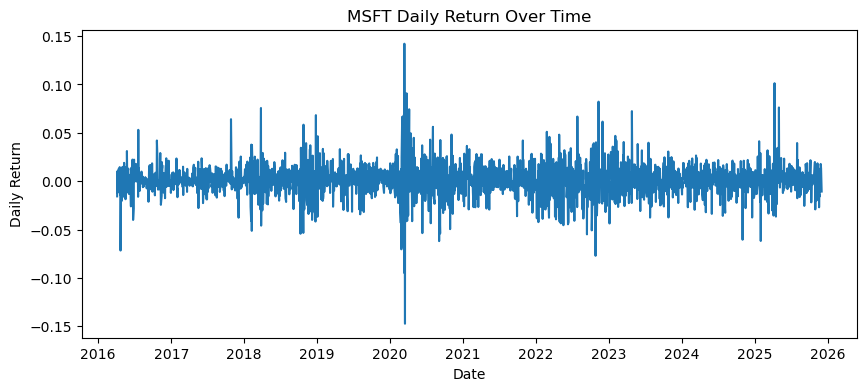

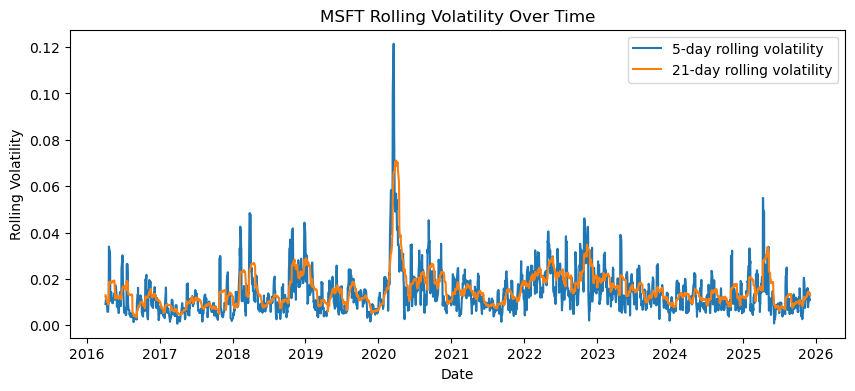

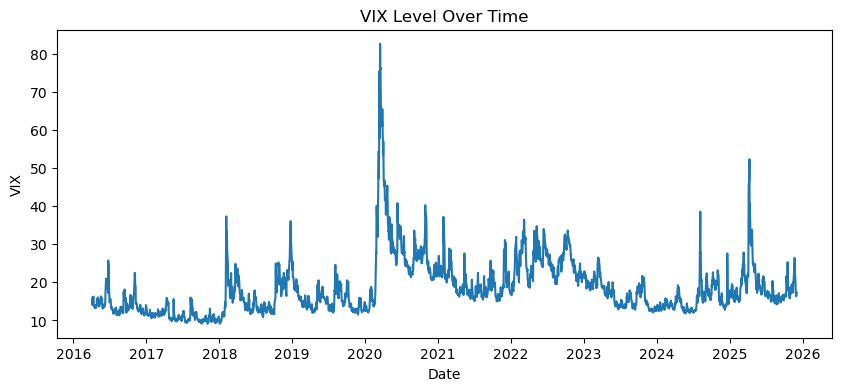

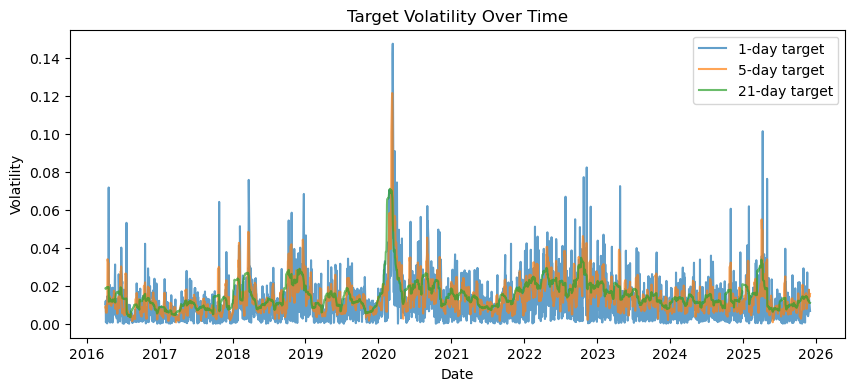

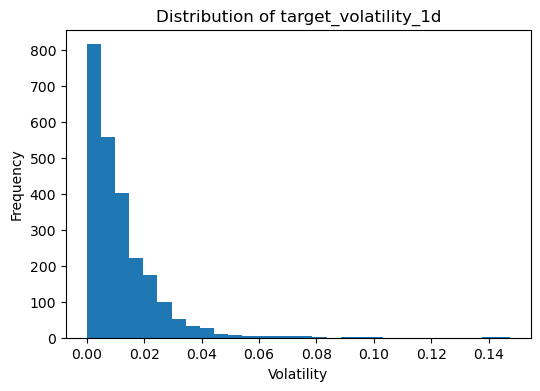

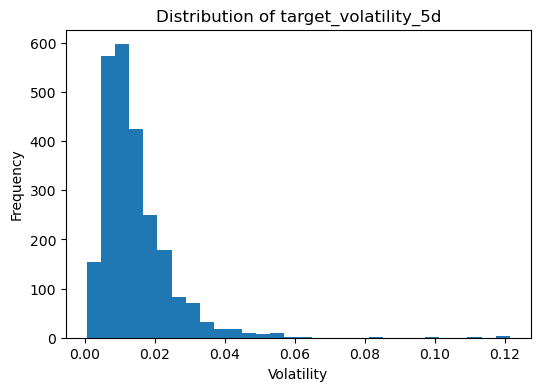

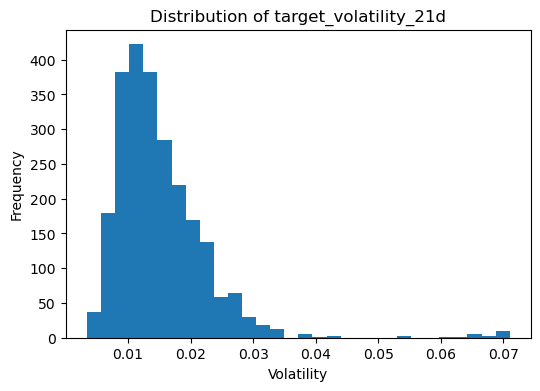

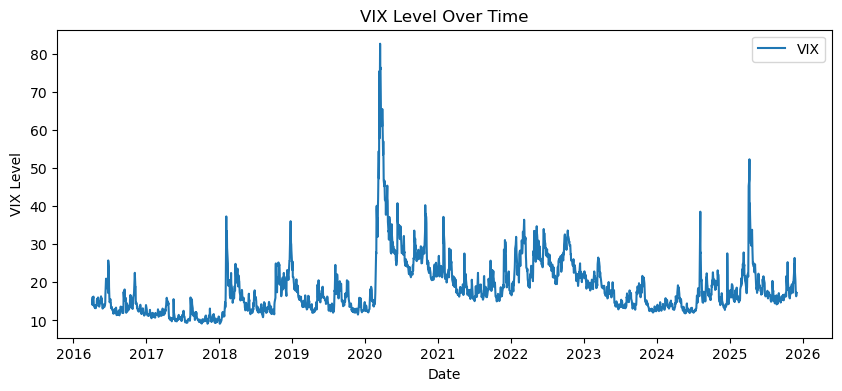

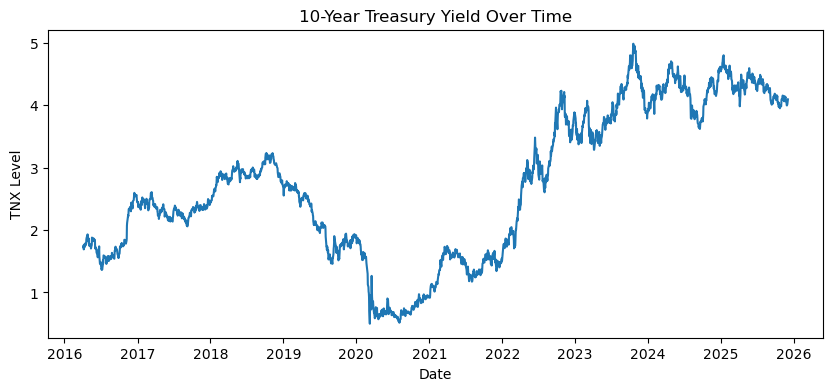

In [19]:
# Example visualization
# plt.figure(figsize=(6,4))
# df['your_column'].hist(bins=30)
# plt.title('Distribution of your_column')
# plt.show()

# =========================
# 3.2 MSFT daily return over time
# =========================

plt.figure(figsize=(10, 4))
plt.plot(model_data.index, model_data['MSFT_return_1d'])
plt.title('MSFT Daily Return Over Time')
plt.xlabel('Date')
plt.ylabel('Daily Return')
plt.show()

# =========================
# 3.3 MSFT rolling volatility
# =========================

plt.figure(figsize=(10, 4))
plt.plot(model_data.index, model_data['MSFT_rolling_vol_5'], label='5-day rolling volatility')
plt.plot(model_data.index, model_data['MSFT_rolling_vol_21'], label='21-day rolling volatility')
plt.title('MSFT Rolling Volatility Over Time')
plt.xlabel('Date')
plt.ylabel('Rolling Volatility')
plt.legend()
plt.show()

# =========================
# 3.4 VIX level over time
# =========================

plt.figure(figsize=(10, 4))
plt.plot(model_data.index, model_data['VIX_level'])
plt.title('VIX Level Over Time')
plt.xlabel('Date')
plt.ylabel('VIX')
plt.show()

# =========================
# 3.5 Target variable summary
# =========================

target_cols = [
    'target_volatility_1d',
    'target_volatility_5d',
    'target_volatility_21d'
]

model_data[target_cols].describe()

# =========================
# 3.6 Target volatility over time
# =========================

plt.figure(figsize=(10, 4))
plt.plot(model_data.index, model_data['target_volatility_1d'], label='1-day target', alpha=0.7)
plt.plot(model_data.index, model_data['target_volatility_5d'], label='5-day target', alpha=0.7)
plt.plot(model_data.index, model_data['target_volatility_21d'], label='21-day target', alpha=0.7)
plt.title('Target Volatility Over Time')
plt.xlabel('Date')
plt.ylabel('Volatility')
plt.legend()
plt.show()

# =========================
# 3.7 Distribution of target variables
# =========================

for col in target_cols:
    plt.figure(figsize=(6, 4))
    plt.hist(model_data[col], bins=30)
    plt.title(f'Distribution of {col}')
    plt.xlabel('Volatility')
    plt.ylabel('Frequency')
    plt.show()


# =========================
# 3.8 Additional market features over time
# =========================

plt.figure(figsize=(10, 4))
plt.plot(model_data.index, model_data['VIX_level'], label='VIX')
plt.title('VIX Level Over Time')
plt.xlabel('Date')
plt.ylabel('VIX Level')
plt.legend()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(model_data.index, model_data['TNX_level'])
plt.title('10-Year Treasury Yield Over Time')
plt.xlabel('Date')
plt.ylabel('TNX Level')
plt.show()

# 4. Methodology

Clearly separate the problem description from the learning algorithms.

Include a separate subsection for hyperparameter tuning:
- Explain how tuning is performed.
- Make the comparison fair across models.
- State the validation procedure clearly.

## 4.1 Overview of Models
- You must try at least as many algorithms as group members.
- Each group member should implement at least one algorithm.
- Use models within the scope of the course.
- If using a more advanced model, provide sufficient background and compare it against standard baselines first.


## 4.2 Model 1: Support Vector Regression (SVR)

**Implemented by: Jenny Fu** 

- Motivation

Support Vector Regression (SVR) is chosen because future MSFT volatility may not have a simple linear relationship with the input features. Variables such as VIX, VXN, market returns, lagged MSFT returns, and rolling volatility may affect future volatility in a nonlinear way. Compared with linear regression, SVR can use a kernel function to fit a more flexible regression relationship.

SVR is also useful because financial data are noisy. It allows small prediction errors within an epsilon margin, and only penalizes errors outside that margin. This fits our task because small volatility prediction errors are acceptable, while larger errors should be penalized.

- Model description

Support Vector Regression is the regression version of SVM. Instead of separating classes, SVR fits a function to predict a continuous target:

f(x) = w^T x + b

A key idea is the epsilon-insensitive tube. If the prediction error is within ε, there is no penalty. If the error is larger than ε, the point is outside the tube and receives a penalty.

In this project, we use SVR with an RBF kernel to capture possible nonlinear relationships between market features and future MSFT volatility. The main parameters are C, ε, and gamma. C controls the penalty strength, ε controls the tube width, and gamma controls the flexibility of the RBF kernel.

- Why this method is appropriate/Key assumptions

SVR is appropriate because stock volatility may depend on nonlinear combinations of past returns, rolling volatility, market indexes, sector ETFs, and volatility indexes. It also works reasonably well for medium-sized datasets like our 10 years of daily stock data.

The main assumption is that past and current market information contains some signal about future volatility. We also split the data chronologically to avoid using future information. Since SVR is sensitive to feature scale, we standardize the features using only the training set and apply the same scaler to the validation and test sets.

In [20]:
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

param_grid = [
    {'C': 0.1, 'epsilon': 0.001, 'gamma': 'scale'},
    {'C': 1, 'epsilon': 0.001, 'gamma': 'scale'},
    {'C': 10, 'epsilon': 0.001, 'gamma': 'scale'},
    {'C': 1, 'epsilon': 0.005, 'gamma': 'scale'},
    {'C': 10, 'epsilon': 0.005, 'gamma': 'scale'},
    {'C': 1, 'epsilon': 0.01, 'gamma': 'scale'},
    {'C': 10, 'epsilon': 0.01, 'gamma': 'scale'}
]

In [21]:
# =========================
# SVR Model: 1-day volatility target
# =========================

y_train = y_train_1d
y_valid = y_valid_1d
y_test = y_test_1d

best_valid_rmse_1d = np.inf
best_svr_1d = None
best_params_1d = None
best_valid_pred_1d = None

for params in param_grid:
    svr = SVR(
        kernel='rbf',
        C=params['C'],
        epsilon=params['epsilon'],
        gamma=params['gamma']
    )
    
    # Train on training set
    svr.fit(X_train_scaled, y_train)
    
    # Evaluate on validation set
    y_valid_pred = svr.predict(X_valid_scaled)
    valid_rmse = np.sqrt(mean_squared_error(y_valid, y_valid_pred))
    
    # Select best hyperparameters using validation RMSE
    if valid_rmse < best_valid_rmse_1d:
        best_valid_rmse_1d = valid_rmse
        best_svr_1d = svr
        best_params_1d = params
        best_valid_pred_1d = y_valid_pred

print("Best parameters for 1-day target:", best_params_1d)
print("Best validation RMSE for 1-day target:", best_valid_rmse_1d)

# Validation metrics
valid_mae_1d = mean_absolute_error(y_valid, best_valid_pred_1d)
valid_rmse_1d = np.sqrt(mean_squared_error(y_valid, best_valid_pred_1d))
valid_r2_1d = r2_score(y_valid, best_valid_pred_1d)
valid_normalized_rmse_1d = valid_rmse_1d / np.std(y_valid)

# Test prediction using the selected best model
y_test_pred_1d = best_svr_1d.predict(X_test_scaled)

# Test metrics
test_mae_1d = mean_absolute_error(y_test, y_test_pred_1d)
test_rmse_1d = np.sqrt(mean_squared_error(y_test, y_test_pred_1d))
test_r2_1d = r2_score(y_test, y_test_pred_1d)
test_normalized_rmse_1d = test_rmse_1d / np.std(y_test)

# Naive baseline on test set
baseline_pred_1d = np.repeat(y_train.mean(), len(y_test))
baseline_rmse_1d = np.sqrt(mean_squared_error(y_test, baseline_pred_1d))
improvement_1d = (baseline_rmse_1d - test_rmse_1d) / baseline_rmse_1d

print("\nSVR 1-day Validation Results")
print("Validation MAE:", valid_mae_1d)
print("Validation RMSE:", valid_rmse_1d)
print("Validation Normalized RMSE:", valid_normalized_rmse_1d)
print("Validation R2:", valid_r2_1d)

print("\nSVR 1-day Test Results")
print("Test MAE:", test_mae_1d)
print("Test RMSE:", test_rmse_1d)
print("Test Normalized RMSE:", test_normalized_rmse_1d)
print("Test R2:", test_r2_1d)
print("Baseline RMSE:", baseline_rmse_1d)
print("Improvement over baseline:", improvement_1d)

Best parameters for 1-day target: {'C': 0.1, 'epsilon': 0.001, 'gamma': 'scale'}
Best validation RMSE for 1-day target: 0.010167441892705806

SVR 1-day Validation Results
Validation MAE: 0.007720051256700242
Validation RMSE: 0.010167441892705806
Validation Normalized RMSE: 1.071237277759391
Validation R2: -0.14754930526135102

SVR 1-day Test Results
Test MAE: 0.00869301860684088
Test RMSE: 0.012110557722356724
Test Normalized RMSE: 1.1326296257149187
Test R2: -0.28284986904711595
Baseline RMSE: 0.010887484988368288
Improvement over baseline: -0.11233748981469217


In [22]:
# =========================
# SVR Model: 5-day volatility target
# =========================

y_train = y_train_5d
y_valid = y_valid_5d
y_test = y_test_5d

best_valid_rmse_5d = np.inf
best_svr_5d = None
best_params_5d = None
best_valid_pred_5d = None

for params in param_grid:
    svr = SVR(
        kernel='rbf',
        C=params['C'],
        epsilon=params['epsilon'],
        gamma=params['gamma']
    )
    
    # Train on training set
    svr.fit(X_train_scaled, y_train)
    
    # Evaluate on validation set
    y_valid_pred = svr.predict(X_valid_scaled)
    valid_rmse = np.sqrt(mean_squared_error(y_valid, y_valid_pred))
    
    # Select best hyperparameters using validation RMSE
    if valid_rmse < best_valid_rmse_5d:
        best_valid_rmse_5d = valid_rmse
        best_svr_5d = svr
        best_params_5d = params
        best_valid_pred_5d = y_valid_pred

print("Best parameters for 5-day target:", best_params_5d)
print("Best validation RMSE for 5-day target:", best_valid_rmse_5d)

# Validation metrics
valid_mae_5d = mean_absolute_error(y_valid, best_valid_pred_5d)
valid_rmse_5d = np.sqrt(mean_squared_error(y_valid, best_valid_pred_5d))
valid_r2_5d = r2_score(y_valid, best_valid_pred_5d)
valid_normalized_rmse_5d = valid_rmse_5d / np.std(y_valid)

# Test prediction using the selected best model
y_test_pred_5d = best_svr_5d.predict(X_test_scaled)

# Test metrics
test_mae_5d = mean_absolute_error(y_test, y_test_pred_5d)
test_rmse_5d = np.sqrt(mean_squared_error(y_test, y_test_pred_5d))
test_r2_5d = r2_score(y_test, y_test_pred_5d)
test_normalized_rmse_5d = test_rmse_5d / np.std(y_test)

# Naive baseline on test set
baseline_pred_5d = np.repeat(y_train.mean(), len(y_test))
baseline_rmse_5d = np.sqrt(mean_squared_error(y_test, baseline_pred_5d))
improvement_5d = (baseline_rmse_5d - test_rmse_5d) / baseline_rmse_5d

print("\nSVR 5-day Validation Results")
print("Validation MAE:", valid_mae_5d)
print("Validation RMSE:", valid_rmse_5d)
print("Validation Normalized RMSE:", valid_normalized_rmse_5d)
print("Validation R2:", valid_r2_5d)

print("\nSVR 5-day Test Results")
print("Test MAE:", test_mae_5d)
print("Test RMSE:", test_rmse_5d)
print("Test Normalized RMSE:", test_normalized_rmse_5d)
print("Test R2:", test_r2_5d)
print("Baseline RMSE:", baseline_rmse_5d)
print("Improvement over baseline:", improvement_5d)

Best parameters for 5-day target: {'C': 0.1, 'epsilon': 0.001, 'gamma': 'scale'}
Best validation RMSE for 5-day target: 0.008263528103478503

SVR 5-day Validation Results
Validation MAE: 0.006521873883029401
Validation RMSE: 0.008263528103478503
Validation Normalized RMSE: 1.352646198903815
Validation R2: -0.8296517394089395

SVR 5-day Test Results
Test MAE: 0.008654270330997384
Test RMSE: 0.010591573169510789
Test Normalized RMSE: 1.3721356339148212
Test R2: -0.8827561978588285
Baseline RMSE: 0.008030989722593678
Improvement over baseline: -0.3188378438230834


In [23]:
# =========================
# SVR Model: 21-day volatility target
# =========================

y_train = y_train_21d
y_valid = y_valid_21d
y_test = y_test_21d

best_valid_rmse_21d = np.inf
best_svr_21d = None
best_params_21d = None
best_valid_pred_21d = None

for params in param_grid:
    svr = SVR(
        kernel='rbf',
        C=params['C'],
        epsilon=params['epsilon'],
        gamma=params['gamma']
    )
    
    # Train on training set
    svr.fit(X_train_scaled, y_train)
    
    # Evaluate on validation set
    y_valid_pred = svr.predict(X_valid_scaled)
    valid_rmse = np.sqrt(mean_squared_error(y_valid, y_valid_pred))
    
    # Select best hyperparameters using validation RMSE
    if valid_rmse < best_valid_rmse_21d:
        best_valid_rmse_21d = valid_rmse
        best_svr_21d = svr
        best_params_21d = params
        best_valid_pred_21d = y_valid_pred

print("Best parameters for 21-day target:", best_params_21d)
print("Best validation RMSE for 21-day target:", best_valid_rmse_21d)

# Validation metrics
valid_mae_21d = mean_absolute_error(y_valid, best_valid_pred_21d)
valid_rmse_21d = np.sqrt(mean_squared_error(y_valid, best_valid_pred_21d))
valid_r2_21d = r2_score(y_valid, best_valid_pred_21d)
valid_normalized_rmse_21d = valid_rmse_21d / np.std(y_valid)

# Test prediction using the selected best model
y_test_pred_21d = best_svr_21d.predict(X_test_scaled)

# Test metrics
test_mae_21d = mean_absolute_error(y_test, y_test_pred_21d)
test_rmse_21d = np.sqrt(mean_squared_error(y_test, y_test_pred_21d))
test_r2_21d = r2_score(y_test, y_test_pred_21d)
test_normalized_rmse_21d = test_rmse_21d / np.std(y_test)

# Naive baseline on test set
baseline_pred_21d = np.repeat(y_train.mean(), len(y_test))
baseline_rmse_21d = np.sqrt(mean_squared_error(y_test, baseline_pred_21d))
improvement_21d = (baseline_rmse_21d - test_rmse_21d) / baseline_rmse_21d

print("\nSVR 21-day Validation Results")
print("Validation MAE:", valid_mae_21d)
print("Validation RMSE:", valid_rmse_21d)
print("Validation Normalized RMSE:", valid_normalized_rmse_21d)
print("Validation R2:", valid_r2_21d)

print("\nSVR 21-day Test Results")
print("Test MAE:", test_mae_21d)
print("Test RMSE:", test_rmse_21d)
print("Test Normalized RMSE:", test_normalized_rmse_21d)
print("Test R2:", test_r2_21d)
print("Baseline RMSE:", baseline_rmse_21d)
print("Improvement over baseline:", improvement_21d)

Best parameters for 21-day target: {'C': 0.1, 'epsilon': 0.001, 'gamma': 'scale'}
Best validation RMSE for 21-day target: 0.0071581708657655636

SVR 21-day Validation Results
Validation MAE: 0.00604376052119205
Validation RMSE: 0.0071581708657655636
Validation Normalized RMSE: 2.105129533473673
Validation R2: -3.4315703527030887

SVR 21-day Test Results
Test MAE: 0.008180378304616672
Test RMSE: 0.00946310830319442
Test Normalized RMSE: 1.7804179033420826
Test R2: -2.169887910541019
Baseline RMSE: 0.005673873722489611
Improvement over baseline: -0.6678390753896


In [24]:
# =========================
# SVR Summary Table
# =========================

svr_summary = pd.DataFrame({
    "Target": [
        "1-day volatility",
        "5-day volatility",
        "21-day volatility"
    ],
    
    "Best Parameters": [
        best_params_1d,
        best_params_5d,
        best_params_21d
    ],
    
    "Validation RMSE": [
        valid_rmse_1d,
        valid_rmse_5d,
        valid_rmse_21d
    ],
    
    "Validation Normalized RMSE": [
        valid_normalized_rmse_1d,
        valid_normalized_rmse_5d,
        valid_normalized_rmse_21d
    ],
    
    "Test MAE": [
        test_mae_1d,
        test_mae_5d,
        test_mae_21d
    ],
    
    "Test RMSE": [
        test_rmse_1d,
        test_rmse_5d,
        test_rmse_21d
    ],
    
    "Test Normalized RMSE": [
        test_normalized_rmse_1d,
        test_normalized_rmse_5d,
        test_normalized_rmse_21d
    ],
    
    "Test R2": [
        test_r2_1d,
        test_r2_5d,
        test_r2_21d
    ],
    
    "Baseline RMSE": [
        baseline_rmse_1d,
        baseline_rmse_5d,
        baseline_rmse_21d
    ],
    
    "Improvement over Baseline": [
        improvement_1d,
        improvement_5d,
        improvement_21d
    ]
})

svr_summary_rounded = svr_summary.copy()

numeric_cols = [
    "Validation RMSE",
    "Validation Normalized RMSE",
    "Test MAE",
    "Test RMSE",
    "Test Normalized RMSE",
    "Test R2",
    "Baseline RMSE",
    "Improvement over Baseline"
]

svr_summary_rounded[numeric_cols] = svr_summary_rounded[numeric_cols].round(4)

svr_summary_rounded

,Target,Best Parameters,Validation RMSE,Validation Normalized RMSE,Test MAE,Test RMSE,Test Normalized RMSE,Test R2,Baseline RMSE,Improvement over Baseline
0,1-day volatility,"{'C': 0.1, 'epsilon': 0.001, 'gamma': 'scale'}",0.0102,1.0712,0.0087,0.0121,1.1326,-0.2828,0.0109,-0.1123
1,5-day volatility,"{'C': 0.1, 'epsilon': 0.001, 'gamma': 'scale'}",0.0083,1.3526,0.0087,0.0106,1.3721,-0.8828,0.0080,-0.3188
2,21-day volatility,"{'C': 0.1, 'epsilon': 0.001, 'gamma': 'scale'}",0.0072,2.1051,0.0082,0.0095,1.7804,-2.1699,0.0057,-0.6678


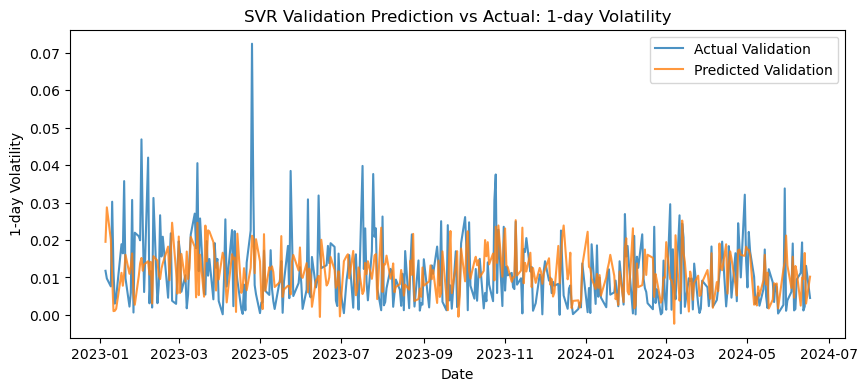

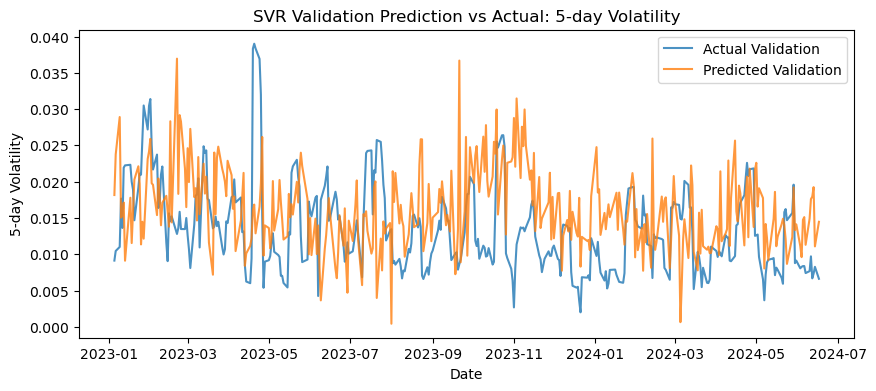

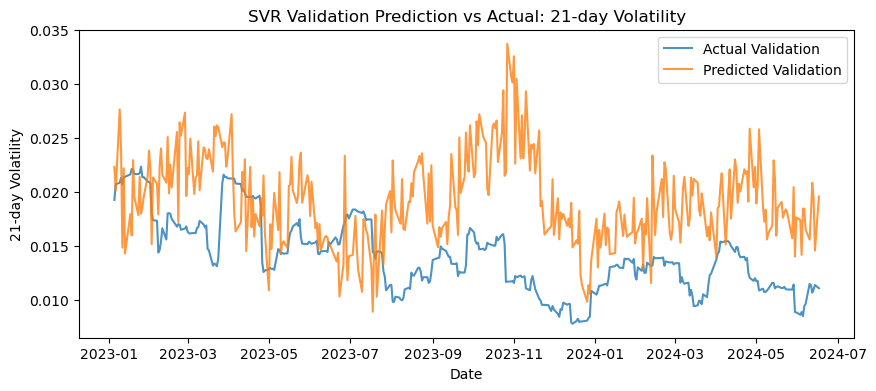

In [25]:
# =========================
# SVR Validation Prediction vs Actual Plots
# =========================

plt.figure(figsize=(10, 4))
plt.plot(valid_data.index, y_valid_1d, label='Actual Validation', alpha=0.8)
plt.plot(valid_data.index, best_valid_pred_1d, label='Predicted Validation', alpha=0.8)
plt.title('SVR Validation Prediction vs Actual: 1-day Volatility')
plt.xlabel('Date')
plt.ylabel('1-day Volatility')
plt.legend()
plt.show()


plt.figure(figsize=(10, 4))
plt.plot(valid_data.index, y_valid_5d, label='Actual Validation', alpha=0.8)
plt.plot(valid_data.index, best_valid_pred_5d, label='Predicted Validation', alpha=0.8)
plt.title('SVR Validation Prediction vs Actual: 5-day Volatility')
plt.xlabel('Date')
plt.ylabel('5-day Volatility')
plt.legend()
plt.show()


plt.figure(figsize=(10, 4))
plt.plot(valid_data.index, y_valid_21d, label='Actual Validation', alpha=0.8)
plt.plot(valid_data.index, best_valid_pred_21d, label='Predicted Validation', alpha=0.8)
plt.title('SVR Validation Prediction vs Actual: 21-day Volatility')
plt.xlabel('Date')
plt.ylabel('21-day Volatility')
plt.legend()
plt.show()

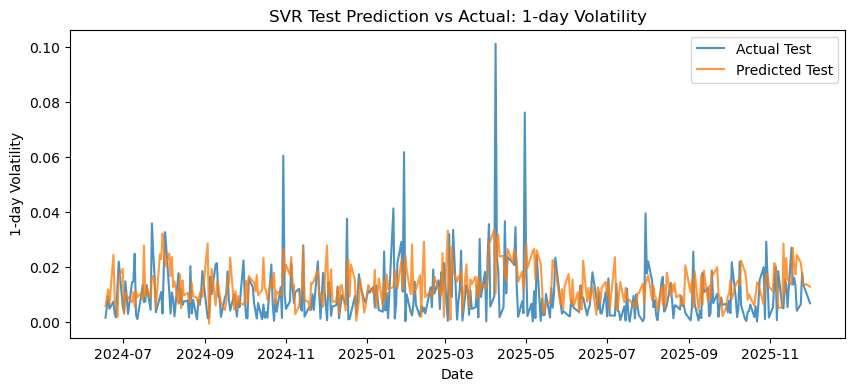

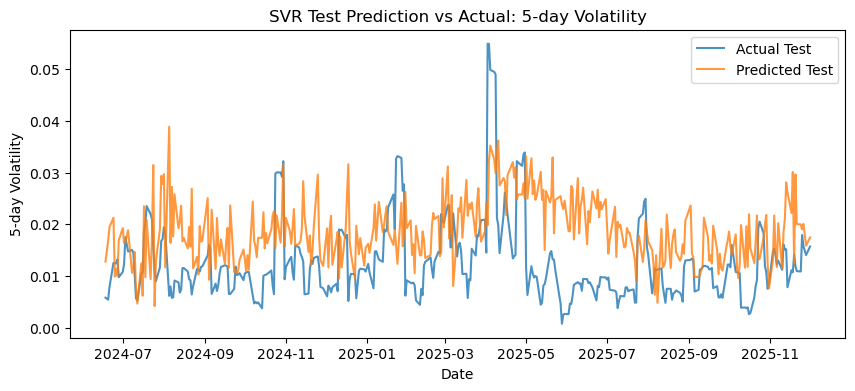

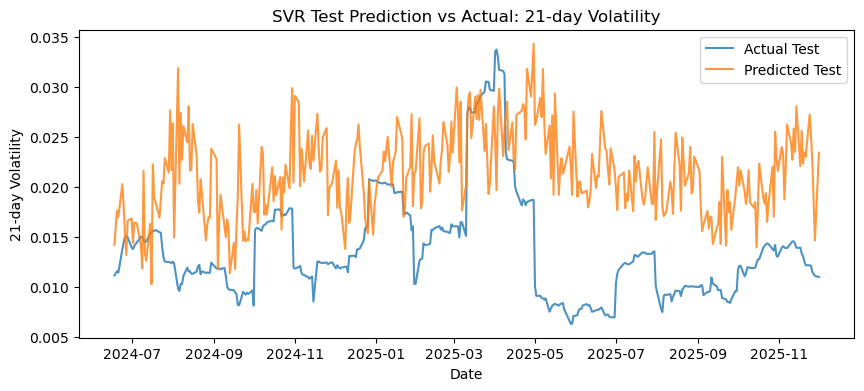

In [26]:
# =========================
# SVR Test Prediction vs Actual Plots
# =========================

plt.figure(figsize=(10, 4))
plt.plot(test_data.index, y_test_1d, label='Actual Test', alpha=0.8)
plt.plot(test_data.index, y_test_pred_1d, label='Predicted Test', alpha=0.8)
plt.title('SVR Test Prediction vs Actual: 1-day Volatility')
plt.xlabel('Date')
plt.ylabel('1-day Volatility')
plt.legend()
plt.show()


plt.figure(figsize=(10, 4))
plt.plot(test_data.index, y_test_5d, label='Actual Test', alpha=0.8)
plt.plot(test_data.index, y_test_pred_5d, label='Predicted Test', alpha=0.8)
plt.title('SVR Test Prediction vs Actual: 5-day Volatility')
plt.xlabel('Date')
plt.ylabel('5-day Volatility')
plt.legend()
plt.show()


plt.figure(figsize=(10, 4))
plt.plot(test_data.index, y_test_21d, label='Actual Test', alpha=0.8)
plt.plot(test_data.index, y_test_pred_21d, label='Predicted Test', alpha=0.8)
plt.title('SVR Test Prediction vs Actual: 21-day Volatility')
plt.xlabel('Date')
plt.ylabel('21-day Volatility')
plt.legend()
plt.show()

In [30]:
# =========================
# Lasso Regression Model
# =========================

from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

alpha_grid = [
    0.00001,
    0.00005,
    0.0001,
    0.0005,
    0.001,
    0.005,
    0.01,
    0.05,
    0.1
]

In [31]:
# =========================
# Lasso Model: 1-day volatility target
# =========================

y_train = y_train_1d
y_valid = y_valid_1d
y_test = y_test_1d

best_valid_rmse_1d_lasso = np.inf
best_lasso_1d = None
best_alpha_1d = None
best_valid_pred_1d_lasso = None

for alpha in alpha_grid:
    lasso = Lasso(alpha=alpha, max_iter=10000, random_state=42)
    
    # Train on training set
    lasso.fit(X_train_scaled, y_train)
    
    # Evaluate on validation set
    y_valid_pred = lasso.predict(X_valid_scaled)
    valid_rmse = np.sqrt(mean_squared_error(y_valid, y_valid_pred))
    
    # Select best alpha using validation RMSE
    if valid_rmse < best_valid_rmse_1d_lasso:
        best_valid_rmse_1d_lasso = valid_rmse
        best_lasso_1d = lasso
        best_alpha_1d = alpha
        best_valid_pred_1d_lasso = y_valid_pred

print("Best alpha for 1-day target:", best_alpha_1d)
print("Best validation RMSE for 1-day target:", best_valid_rmse_1d_lasso)

# Validation metrics
valid_mae_1d_lasso = mean_absolute_error(y_valid, best_valid_pred_1d_lasso)
valid_rmse_1d_lasso = np.sqrt(mean_squared_error(y_valid, best_valid_pred_1d_lasso))
valid_r2_1d_lasso = r2_score(y_valid, best_valid_pred_1d_lasso)
valid_normalized_rmse_1d_lasso = valid_rmse_1d_lasso / np.std(y_valid)

# Test prediction
y_test_pred_1d_lasso = best_lasso_1d.predict(X_test_scaled)

# Test metrics
test_mae_1d_lasso = mean_absolute_error(y_test, y_test_pred_1d_lasso)
test_rmse_1d_lasso = np.sqrt(mean_squared_error(y_test, y_test_pred_1d_lasso))
test_r2_1d_lasso = r2_score(y_test, y_test_pred_1d_lasso)
test_normalized_rmse_1d_lasso = test_rmse_1d_lasso / np.std(y_test)

# Naive baseline on test set
baseline_pred_1d_lasso = np.repeat(y_train.mean(), len(y_test))
baseline_rmse_1d_lasso = np.sqrt(mean_squared_error(y_test, baseline_pred_1d_lasso))
improvement_1d_lasso = (baseline_rmse_1d_lasso - test_rmse_1d_lasso) / baseline_rmse_1d_lasso

print("\nLasso 1-day Validation Results")
print("Validation MAE:", valid_mae_1d_lasso)
print("Validation RMSE:", valid_rmse_1d_lasso)
print("Validation Normalized RMSE:", valid_normalized_rmse_1d_lasso)
print("Validation R2:", valid_r2_1d_lasso)

print("\nLasso 1-day Test Results")
print("Test MAE:", test_mae_1d_lasso)
print("Test RMSE:", test_rmse_1d_lasso)
print("Test Normalized RMSE:", test_normalized_rmse_1d_lasso)
print("Test R2:", test_r2_1d_lasso)
print("Baseline RMSE:", baseline_rmse_1d_lasso)
print("Improvement over baseline:", improvement_1d_lasso)

Best alpha for 1-day target: 0.0005
Best validation RMSE for 1-day target: 0.009149613538353302

Lasso 1-day Validation Results
Validation MAE: 0.007019350276471627
Validation RMSE: 0.009149613538353302
Validation Normalized RMSE: 0.9639993228196031
Validation R2: 0.07070530560334631

Lasso 1-day Test Results
Test MAE: 0.007472988062305331
Test RMSE: 0.010455273990007716
Test Normalized RMSE: 0.9778206204482638
Test R2: 0.0438668342261731
Baseline RMSE: 0.010887484988368288
Improvement over baseline: 0.03969796503254215


In [32]:
# =========================
# Lasso Model: 5-day volatility target
# =========================

y_train = y_train_5d
y_valid = y_valid_5d
y_test = y_test_5d

best_valid_rmse_5d_lasso = np.inf
best_lasso_5d = None
best_alpha_5d = None
best_valid_pred_5d_lasso = None

for alpha in alpha_grid:
    lasso = Lasso(alpha=alpha, max_iter=10000, random_state=42)
    
    # Train on training set
    lasso.fit(X_train_scaled, y_train)
    
    # Evaluate on validation set
    y_valid_pred = lasso.predict(X_valid_scaled)
    valid_rmse = np.sqrt(mean_squared_error(y_valid, y_valid_pred))
    
    # Select best alpha using validation RMSE
    if valid_rmse < best_valid_rmse_5d_lasso:
        best_valid_rmse_5d_lasso = valid_rmse
        best_lasso_5d = lasso
        best_alpha_5d = alpha
        best_valid_pred_5d_lasso = y_valid_pred

print("Best alpha for 5-day target:", best_alpha_5d)
print("Best validation RMSE for 5-day target:", best_valid_rmse_5d_lasso)

# Validation metrics
valid_mae_5d_lasso = mean_absolute_error(y_valid, best_valid_pred_5d_lasso)
valid_rmse_5d_lasso = np.sqrt(mean_squared_error(y_valid, best_valid_pred_5d_lasso))
valid_r2_5d_lasso = r2_score(y_valid, best_valid_pred_5d_lasso)
valid_normalized_rmse_5d_lasso = valid_rmse_5d_lasso / np.std(y_valid)

# Test prediction
y_test_pred_5d_lasso = best_lasso_5d.predict(X_test_scaled)

# Test metrics
test_mae_5d_lasso = mean_absolute_error(y_test, y_test_pred_5d_lasso)
test_rmse_5d_lasso = np.sqrt(mean_squared_error(y_test, y_test_pred_5d_lasso))
test_r2_5d_lasso = r2_score(y_test, y_test_pred_5d_lasso)
test_normalized_rmse_5d_lasso = test_rmse_5d_lasso / np.std(y_test)

# Naive baseline on test set
baseline_pred_5d_lasso = np.repeat(y_train.mean(), len(y_test))
baseline_rmse_5d_lasso = np.sqrt(mean_squared_error(y_test, baseline_pred_5d_lasso))
improvement_5d_lasso = (baseline_rmse_5d_lasso - test_rmse_5d_lasso) / baseline_rmse_5d_lasso

print("\nLasso 5-day Validation Results")
print("Validation MAE:", valid_mae_5d_lasso)
print("Validation RMSE:", valid_rmse_5d_lasso)
print("Validation Normalized RMSE:", valid_normalized_rmse_5d_lasso)
print("Validation R2:", valid_r2_5d_lasso)

print("\nLasso 5-day Test Results")
print("Test MAE:", test_mae_5d_lasso)
print("Test RMSE:", test_rmse_5d_lasso)
print("Test Normalized RMSE:", test_normalized_rmse_5d_lasso)
print("Test R2:", test_r2_5d_lasso)
print("Baseline RMSE:", baseline_rmse_5d_lasso)
print("Improvement over baseline:", improvement_5d_lasso)

Best alpha for 5-day target: 0.001
Best validation RMSE for 5-day target: 0.0058111240529364755

Lasso 5-day Validation Results
Validation MAE: 0.004383887154151982
Validation RMSE: 0.0058111240529364755
Validation Normalized RMSE: 0.9512153602108825
Validation R2: 0.09518933849888078

Lasso 5-day Test Results
Test MAE: 0.005440503797524665
Test RMSE: 0.007271724656184266
Test Normalized RMSE: 0.9420500959658946
Test R2: 0.11254161669064888
Baseline RMSE: 0.008030989722593678
Improvement over baseline: 0.09454190487548038


In [33]:
# =========================
# Lasso Model: 21-day volatility target
# =========================

y_train = y_train_21d
y_valid = y_valid_21d
y_test = y_test_21d

best_valid_rmse_21d_lasso = np.inf
best_lasso_21d = None
best_alpha_21d = None
best_valid_pred_21d_lasso = None

for alpha in alpha_grid:
    lasso = Lasso(alpha=alpha, max_iter=10000, random_state=42)
    
    # Train on training set
    lasso.fit(X_train_scaled, y_train)
    
    # Evaluate on validation set
    y_valid_pred = lasso.predict(X_valid_scaled)
    valid_rmse = np.sqrt(mean_squared_error(y_valid, y_valid_pred))
    
    # Select best alpha using validation RMSE
    if valid_rmse < best_valid_rmse_21d_lasso:
        best_valid_rmse_21d_lasso = valid_rmse
        best_lasso_21d = lasso
        best_alpha_21d = alpha
        best_valid_pred_21d_lasso = y_valid_pred

print("Best alpha for 21-day target:", best_alpha_21d)
print("Best validation RMSE for 21-day target:", best_valid_rmse_21d_lasso)

# Validation metrics
valid_mae_21d_lasso = mean_absolute_error(y_valid, best_valid_pred_21d_lasso)
valid_rmse_21d_lasso = np.sqrt(mean_squared_error(y_valid, best_valid_pred_21d_lasso))
valid_r2_21d_lasso = r2_score(y_valid, best_valid_pred_21d_lasso)
valid_normalized_rmse_21d_lasso = valid_rmse_21d_lasso / np.std(y_valid)

# Test prediction
y_test_pred_21d_lasso = best_lasso_21d.predict(X_test_scaled)

# Test metrics
test_mae_21d_lasso = mean_absolute_error(y_test, y_test_pred_21d_lasso)
test_rmse_21d_lasso = np.sqrt(mean_squared_error(y_test, y_test_pred_21d_lasso))
test_r2_21d_lasso = r2_score(y_test, y_test_pred_21d_lasso)
test_normalized_rmse_21d_lasso = test_rmse_21d_lasso / np.std(y_test)

# Naive baseline on test set
baseline_pred_21d_lasso = np.repeat(y_train.mean(), len(y_test))
baseline_rmse_21d_lasso = np.sqrt(mean_squared_error(y_test, baseline_pred_21d_lasso))
improvement_21d_lasso = (baseline_rmse_21d_lasso - test_rmse_21d_lasso) / baseline_rmse_21d_lasso

print("\nLasso 21-day Validation Results")
print("Validation MAE:", valid_mae_21d_lasso)
print("Validation RMSE:", valid_rmse_21d_lasso)
print("Validation Normalized RMSE:", valid_normalized_rmse_21d_lasso)
print("Validation R2:", valid_r2_21d_lasso)

print("\nLasso 21-day Test Results")
print("Test MAE:", test_mae_21d_lasso)
print("Test RMSE:", test_rmse_21d_lasso)
print("Test Normalized RMSE:", test_normalized_rmse_21d_lasso)
print("Test R2:", test_r2_21d_lasso)
print("Baseline RMSE:", baseline_rmse_21d_lasso)
print("Improvement over baseline:", improvement_21d_lasso)

Best alpha for 21-day target: 0.001
Best validation RMSE for 21-day target: 0.002866872714620052

Lasso 21-day Validation Results
Validation MAE: 0.002285037194924921
Validation RMSE: 0.002866872714620052
Validation Normalized RMSE: 0.8431118135388427
Validation R2: 0.28916246987124294

Lasso 21-day Test Results
Test MAE: 0.003811661666771289
Test RMSE: 0.005023477674695273
Test Normalized RMSE: 0.9451323288826323
Test R2: 0.10672488090089138
Baseline RMSE: 0.005673873722489611
Improvement over baseline: 0.11462998290151477


In [34]:
# =========================
# Lasso Summary Table
# =========================

lasso_summary = pd.DataFrame({
    "Target": [
        "1-day volatility",
        "5-day volatility",
        "21-day volatility"
    ],
    
    "Best Alpha": [
        best_alpha_1d,
        best_alpha_5d,
        best_alpha_21d
    ],
    
    "Validation RMSE": [
        valid_rmse_1d_lasso,
        valid_rmse_5d_lasso,
        valid_rmse_21d_lasso
    ],
    
    "Validation Normalized RMSE": [
        valid_normalized_rmse_1d_lasso,
        valid_normalized_rmse_5d_lasso,
        valid_normalized_rmse_21d_lasso
    ],
    
    "Test MAE": [
        test_mae_1d_lasso,
        test_mae_5d_lasso,
        test_mae_21d_lasso
    ],
    
    "Test RMSE": [
        test_rmse_1d_lasso,
        test_rmse_5d_lasso,
        test_rmse_21d_lasso
    ],
    
    "Test Normalized RMSE": [
        test_normalized_rmse_1d_lasso,
        test_normalized_rmse_5d_lasso,
        test_normalized_rmse_21d_lasso
    ],
    
    "Test R2": [
        test_r2_1d_lasso,
        test_r2_5d_lasso,
        test_r2_21d_lasso
    ],
    
    "Baseline RMSE": [
        baseline_rmse_1d_lasso,
        baseline_rmse_5d_lasso,
        baseline_rmse_21d_lasso
    ],
    
    "Improvement over Baseline": [
        improvement_1d_lasso,
        improvement_5d_lasso,
        improvement_21d_lasso
    ]
})

lasso_summary_rounded = lasso_summary.copy()

numeric_cols = [
    "Best Alpha",
    "Validation RMSE",
    "Validation Normalized RMSE",
    "Test MAE",
    "Test RMSE",
    "Test Normalized RMSE",
    "Test R2",
    "Baseline RMSE",
    "Improvement over Baseline"
]

lasso_summary_rounded[numeric_cols] = lasso_summary_rounded[numeric_cols].round(4)

lasso_summary_rounded

,Target,Best Alpha,Validation RMSE,Validation Normalized RMSE,Test MAE,Test RMSE,Test Normalized RMSE,Test R2,Baseline RMSE,Improvement over Baseline
0,1-day volatility,0.0005,0.0091,0.9640,0.0075,0.0105,0.9778,0.0439,0.0109,0.0397
1,5-day volatility,0.0010,0.0058,0.9512,0.0054,0.0073,0.9421,0.1125,0.0080,0.0945
2,21-day volatility,0.0010,0.0029,0.8431,0.0038,0.0050,0.9451,0.1067,0.0057,0.1146


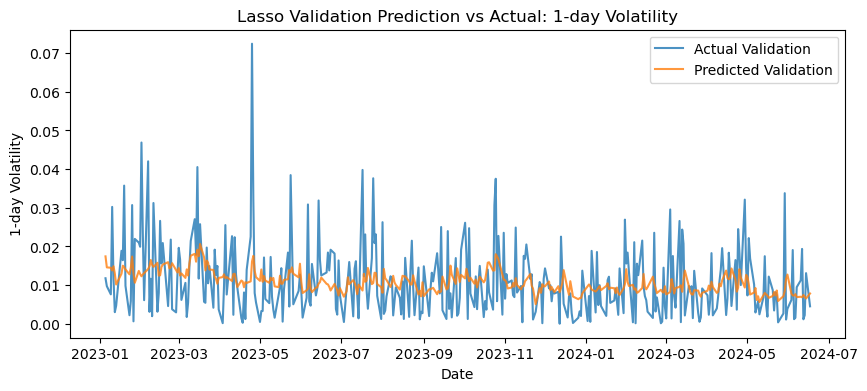

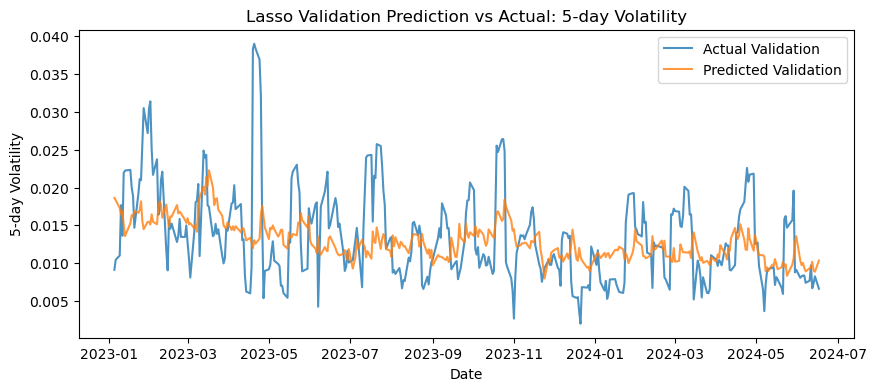

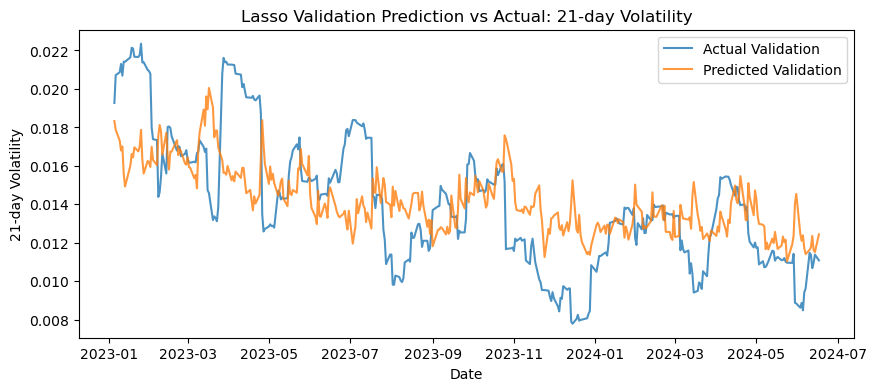

In [35]:
# =========================
# Lasso Validation Prediction vs Actual Plots
# =========================

plt.figure(figsize=(10, 4))
plt.plot(valid_data.index, y_valid_1d, label='Actual Validation', alpha=0.8)
plt.plot(valid_data.index, best_valid_pred_1d_lasso, label='Predicted Validation', alpha=0.8)
plt.title('Lasso Validation Prediction vs Actual: 1-day Volatility')
plt.xlabel('Date')
plt.ylabel('1-day Volatility')
plt.legend()
plt.show()


plt.figure(figsize=(10, 4))
plt.plot(valid_data.index, y_valid_5d, label='Actual Validation', alpha=0.8)
plt.plot(valid_data.index, best_valid_pred_5d_lasso, label='Predicted Validation', alpha=0.8)
plt.title('Lasso Validation Prediction vs Actual: 5-day Volatility')
plt.xlabel('Date')
plt.ylabel('5-day Volatility')
plt.legend()
plt.show()


plt.figure(figsize=(10, 4))
plt.plot(valid_data.index, y_valid_21d, label='Actual Validation', alpha=0.8)
plt.plot(valid_data.index, best_valid_pred_21d_lasso, label='Predicted Validation', alpha=0.8)
plt.title('Lasso Validation Prediction vs Actual: 21-day Volatility')
plt.xlabel('Date')
plt.ylabel('21-day Volatility')
plt.legend()
plt.show()

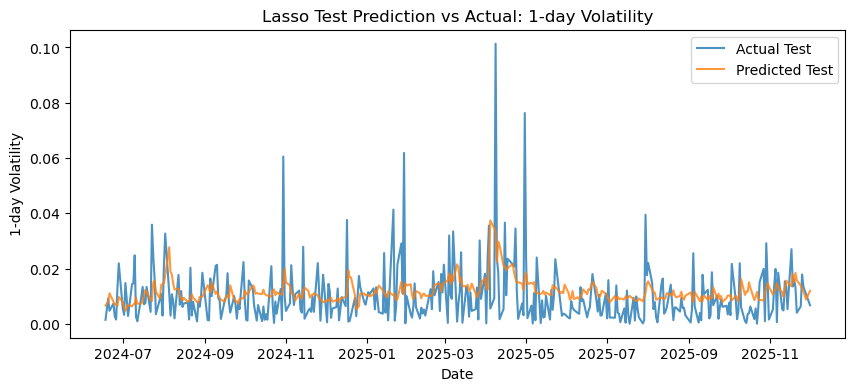

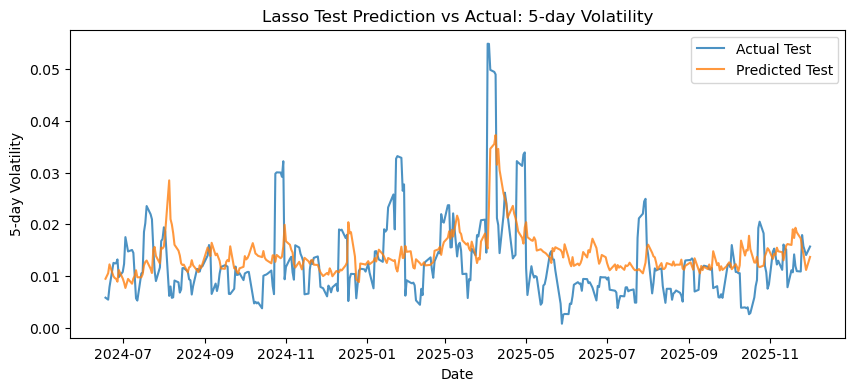

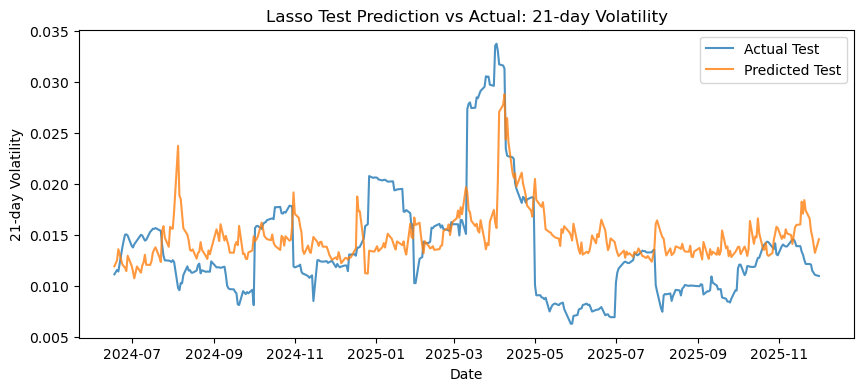

In [36]:
# =========================
# Lasso Test Prediction vs Actual Plots
# =========================

plt.figure(figsize=(10, 4))
plt.plot(test_data.index, y_test_1d, label='Actual Test', alpha=0.8)
plt.plot(test_data.index, y_test_pred_1d_lasso, label='Predicted Test', alpha=0.8)
plt.title('Lasso Test Prediction vs Actual: 1-day Volatility')
plt.xlabel('Date')
plt.ylabel('1-day Volatility')
plt.legend()
plt.show()


plt.figure(figsize=(10, 4))
plt.plot(test_data.index, y_test_5d, label='Actual Test', alpha=0.8)
plt.plot(test_data.index, y_test_pred_5d_lasso, label='Predicted Test', alpha=0.8)
plt.title('Lasso Test Prediction vs Actual: 5-day Volatility')
plt.xlabel('Date')
plt.ylabel('5-day Volatility')
plt.legend()
plt.show()


plt.figure(figsize=(10, 4))
plt.plot(test_data.index, y_test_21d, label='Actual Test', alpha=0.8)
plt.plot(test_data.index, y_test_pred_21d_lasso, label='Predicted Test', alpha=0.8)
plt.title('Lasso Test Prediction vs Actual: 21-day Volatility')
plt.xlabel('Date')
plt.ylabel('21-day Volatility')
plt.legend()
plt.show()

## 4.3 Model 2: Gradient Boost

**Implemented by: Emma Xu** 

- Motivation

    Gradient Boosting is used because stock volatility is likely driven by nonlinear relationships among market variables. For example, the effect of VIX on MSFT volatility may become stronger during high-volatility periods, and recent MSFT volatility may interact with market-wide volatility measures such as SPY and XLK rolling volatility. A simple linear model may not fully capture these nonlinear patterns.

- Model description

    Gradient Boosting is an ensemble learning method that builds many decision trees sequentially. Each new tree is trained to correct the prediction errors made by the previous trees. Instead of fitting one large tree, the model combines many small trees to gradually improve prediction accuracy.

- Why this method is appropriate

    This method is appropriate for volatility prediction because financial volatility often has nonlinear behavior, volatility clustering, and interactions between stock-specific and market-wide variables. Gradient Boosting can capture these complex patterns without requiring us to manually specify nonlinear terms.


Repeat until Model N (N=your group size)

Best Gradient Boosting validation performance:


,Horizon,n_estimators,learning_rate,max_depth,Validation MAE,Validation RMSE,Validation Normalized MAE,Validation R2
0,Daily 1D,200,0.01,2,0.006988,0.009136,0.627925,0.073480
1,Weekly 5D,50,0.01,2,0.004556,0.005843,0.337129,0.085124
2,Monthly 21D,50,0.01,2,0.003063,0.003635,0.218358,-0.143058


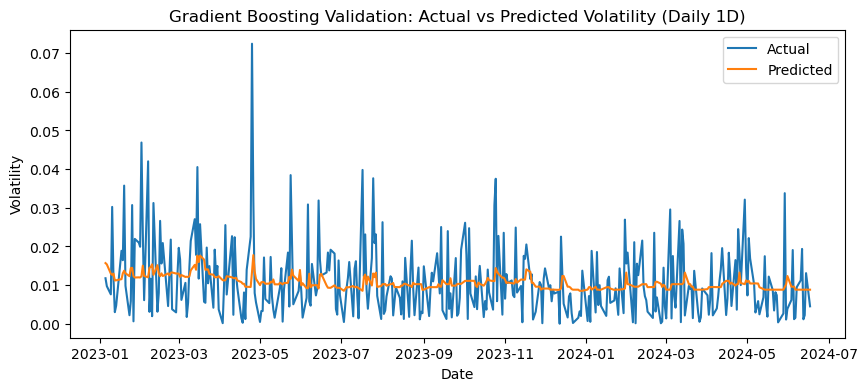

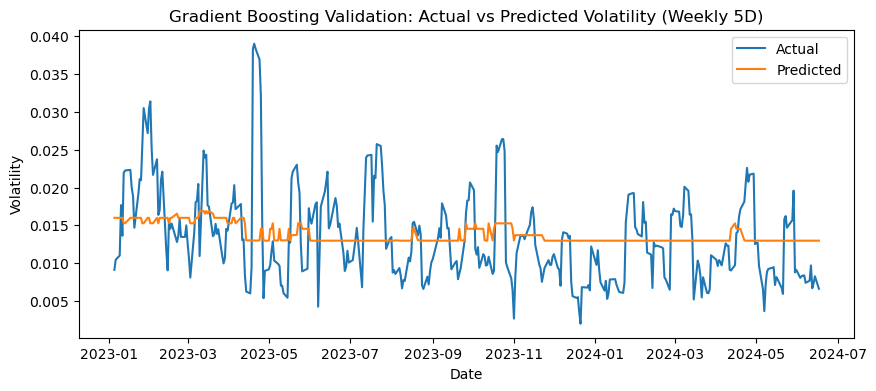

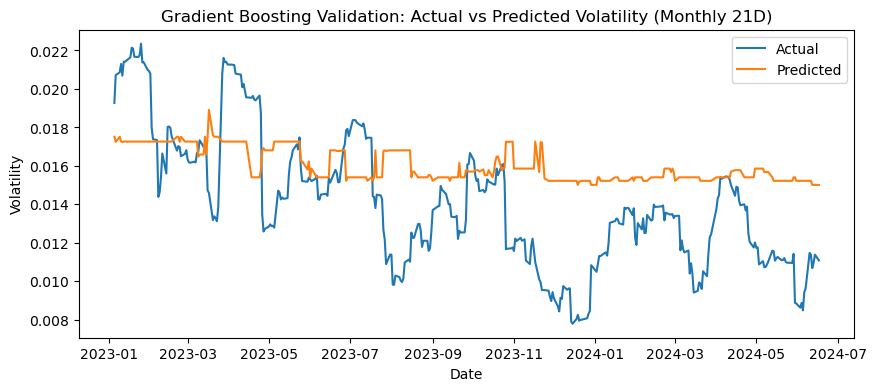

In [27]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

horizon_order = ['Daily 1D', 'Weekly 5D', 'Monthly 21D']

# Targets for validation tuning
targets = {
    'Daily 1D': (y_train_1d, y_valid_1d),
    'Weekly 5D': (y_train_5d, y_valid_5d),
    'Monthly 21D': (y_train_21d, y_valid_21d)
}

# Candidate hyperparameters
param_grid = [
    {'n_estimators': 50, 'learning_rate': 0.01, 'max_depth': 2},
    {'n_estimators': 50, 'learning_rate': 0.03, 'max_depth': 2},
    {'n_estimators': 50, 'learning_rate': 0.05, 'max_depth': 2},
    {'n_estimators': 100, 'learning_rate': 0.01, 'max_depth': 2},
    {'n_estimators': 100, 'learning_rate': 0.03, 'max_depth': 2},
    {'n_estimators': 100, 'learning_rate': 0.05, 'max_depth': 2},
    {'n_estimators': 200, 'learning_rate': 0.01, 'max_depth': 2},
    {'n_estimators': 200, 'learning_rate': 0.03, 'max_depth': 2},
    {'n_estimators': 200, 'learning_rate': 0.05, 'max_depth': 2},
    {'n_estimators': 300, 'learning_rate': 0.01, 'max_depth': 2},
    {'n_estimators': 300, 'learning_rate': 0.03, 'max_depth': 2},
    {'n_estimators': 300, 'learning_rate': 0.05, 'max_depth': 2},
]

tuning_results = []

for horizon in horizon_order:
    
    y_train, y_valid = targets[horizon]
    
    for params in param_grid:
        
        model = GradientBoostingRegressor(
            n_estimators=params['n_estimators'],
            learning_rate=params['learning_rate'],
            max_depth=params['max_depth'],
            random_state=42
        )
        
        # Train on training set only
        model.fit(X_train_scaled, y_train)
        
        # Predict on validation set only
        y_valid_pred = model.predict(X_valid_scaled)
        
        valid_mae = mean_absolute_error(y_valid, y_valid_pred)
        valid_rmse = np.sqrt(mean_squared_error(y_valid, y_valid_pred))
        valid_r2 = r2_score(y_valid, y_valid_pred)
        valid_normalized_mae = valid_mae / y_valid.mean()
        
        tuning_results.append({
            'Horizon': horizon,
            'n_estimators': params['n_estimators'],
            'learning_rate': params['learning_rate'],
            'max_depth': params['max_depth'],
            'Validation MAE': valid_mae,
            'Validation RMSE': valid_rmse,
            'Validation Normalized MAE': valid_normalized_mae,
            'Validation R2': valid_r2
        })

tuning_results_df = pd.DataFrame(tuning_results)

# Sort full tuning table by horizon and normalized MAE
tuning_results_df['Horizon'] = pd.Categorical(
    tuning_results_df['Horizon'],
    categories=horizon_order,
    ordered=True
)

tuning_results_df = (
    tuning_results_df
    .sort_values(['Horizon', 'Validation Normalized MAE'])
    .reset_index(drop=True)
)

tuning_results_df

# Select best parameters for each horizon
best_params_by_horizon = (
    tuning_results_df
    .sort_values('Validation Normalized MAE')
    .groupby('Horizon', observed=True)
    .first()
    .reset_index()
)

best_params_by_horizon['Horizon'] = pd.Categorical(
    best_params_by_horizon['Horizon'],
    categories=horizon_order,
    ordered=True
)

best_params_by_horizon = (
    best_params_by_horizon
    .sort_values('Horizon')
    .reset_index(drop=True)
)


# Refit best Gradient Boosting models and plot validation predictions
best_gb_models = {}
best_gb_valid_predictions = {}
best_gb_valid_results = []

for _, row in best_params_by_horizon.iterrows():
    
    horizon = row['Horizon']
    y_train, y_valid = targets[horizon]
    
    model = GradientBoostingRegressor(
        n_estimators=int(row['n_estimators']),
        learning_rate=float(row['learning_rate']),
        max_depth=int(row['max_depth']),
        random_state=42
    )
    
    # Train on training set only
    model.fit(X_train_scaled, y_train)
    
    # Predict on validation set
    y_valid_pred = model.predict(X_valid_scaled)
    
    # Validation metrics
    valid_mae = mean_absolute_error(y_valid, y_valid_pred)
    valid_rmse = np.sqrt(mean_squared_error(y_valid, y_valid_pred))
    valid_r2 = r2_score(y_valid, y_valid_pred)
    valid_normalized_mae = valid_mae / y_valid.mean()
    
    best_gb_valid_results.append({
        'Horizon': horizon,
        'n_estimators': int(row['n_estimators']),
        'learning_rate': float(row['learning_rate']),
        'max_depth': int(row['max_depth']),
        'Validation MAE': valid_mae,
        'Validation RMSE': valid_rmse,
        'Validation Normalized MAE': valid_normalized_mae,
        'Validation R2': valid_r2
    })
    
    best_gb_models[horizon] = model
    best_gb_valid_predictions[horizon] = y_valid_pred

best_gb_valid_results_df = pd.DataFrame(best_gb_valid_results)

best_gb_valid_results_df['Horizon'] = pd.Categorical(
    best_gb_valid_results_df['Horizon'],
    categories=horizon_order,
    ordered=True
)

best_gb_valid_results_df = (
    best_gb_valid_results_df
    .sort_values('Horizon')
    .reset_index(drop=True)
)

print("Best Gradient Boosting validation performance:")
display(best_gb_valid_results_df)

# Validation actual vs predicted plots using best models
for horizon in horizon_order:
    
    y_train, y_valid = targets[horizon]
    y_valid_pred = best_gb_valid_predictions[horizon]
    
    plt.figure(figsize=(10, 4))
    plt.plot(y_valid.index, y_valid, label='Actual')
    plt.plot(y_valid.index, y_valid_pred, label='Predicted')
    plt.title(f'Gradient Boosting Validation: Actual vs Predicted Volatility ({horizon})')
    plt.xlabel('Date')
    plt.ylabel('Volatility')
    plt.legend()
    plt.show()

Top 10 Feature Importances for Daily 1D:


,Feature,Importance
14,VIX_level,0.353343
9,MSFT_log_volume,0.257911
7,MSFT_rolling_vol_5,0.133138
4,MSFT_return_lag10,0.055417
13,SPY_rolling_vol_21,0.045800
10,SPY_return_1d,0.031825
22,TNX_change,0.024056
3,MSFT_return_lag5,0.021126
11,SPY_return_lag1,0.019515
1,MSFT_return_lag1,0.012557


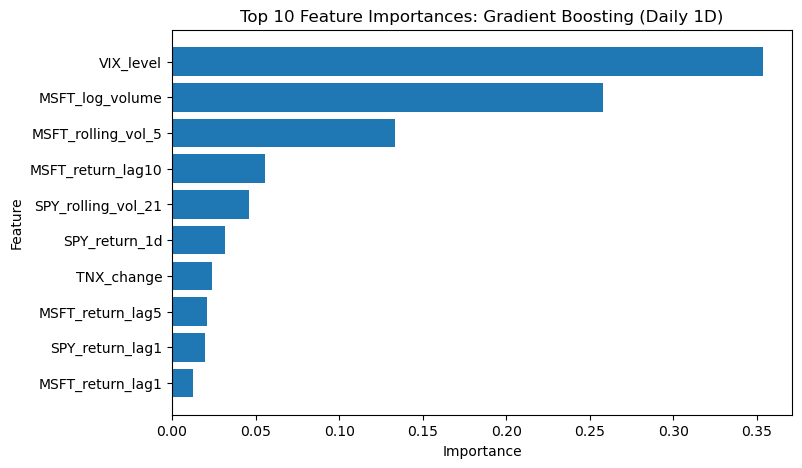

Top 10 Feature Importances for Weekly 5D:


,Feature,Importance
12,SPY_rolling_vol_5,0.501532
14,VIX_level,0.345094
13,SPY_rolling_vol_21,0.076722
25,TLT_rolling_vol_21,0.036536
20,VIX_rolling_mean_21,0.016081
8,MSFT_rolling_vol_21,0.012970
19,MSFT_rolling_vol_63,0.011065
2,MSFT_return_lag3,0.000000
1,MSFT_return_lag1,0.000000
0,MSFT_return_1d,0.000000


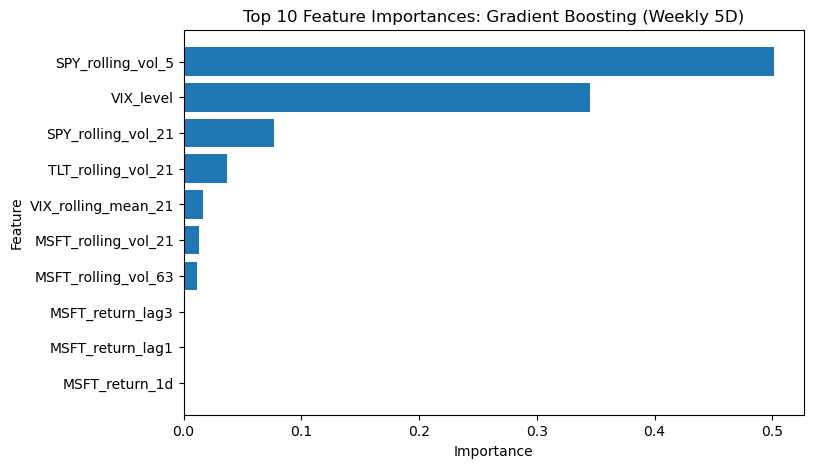

Top 10 Feature Importances for Monthly 21D:


,Feature,Importance
8,MSFT_rolling_vol_21,0.404406
12,SPY_rolling_vol_5,0.243916
14,VIX_level,0.223405
9,MSFT_log_volume,0.036039
19,MSFT_rolling_vol_63,0.035509
13,SPY_rolling_vol_21,0.026031
21,TNX_level,0.022332
20,VIX_rolling_mean_21,0.008363
1,MSFT_return_lag1,0.000000
0,MSFT_return_1d,0.000000


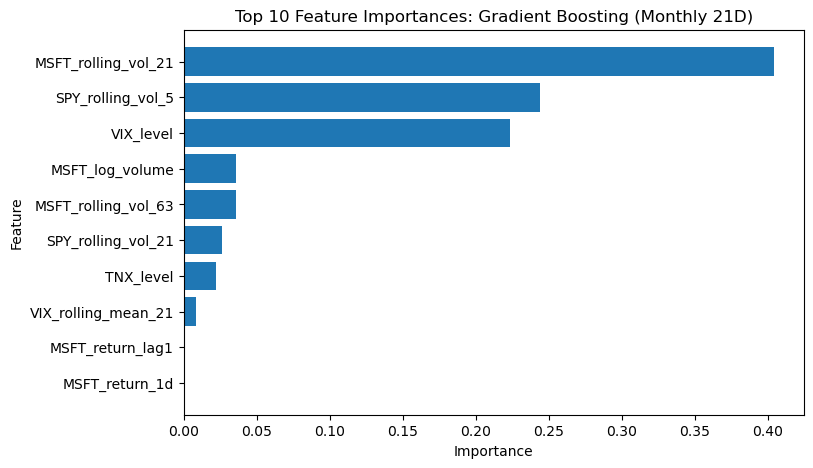

In [28]:
# Feature Importance for Best Gradient Boosting Models
import pandas as pd
import matplotlib.pyplot as plt

feature_importance_dfs = {}

for horizon in horizon_order:
    
    model = best_gb_models[horizon]
    
    importance_df = pd.DataFrame({
        'Feature': feature_cols,
        'Importance': model.feature_importances_
    }).sort_values(by='Importance', ascending=False)
    
    feature_importance_dfs[horizon] = importance_df
    
    print(f"Top 10 Feature Importances for {horizon}:")
    display(importance_df.head(10))
    
    plt.figure(figsize=(8, 5))
    plt.barh(
        importance_df.head(10)['Feature'][::-1],
        importance_df.head(10)['Importance'][::-1]
    )
    plt.title(f'Top 10 Feature Importances: Gradient Boosting ({horizon})')
    plt.xlabel('Importance')
    plt.ylabel('Feature')
    plt.show()

Final Gradient Boosting Test Performance:


,Horizon,n_estimators,learning_rate,max_depth,Test MAE,Test RMSE,Test Normalized MAE,Test R2
0,Daily 1D,200,0.01,2,0.007345,0.010474,0.735981,0.040350
1,Weekly 5D,50,0.01,2,0.005892,0.007924,0.468578,-0.053698
2,Monthly 21D,50,0.01,2,0.004099,0.005246,0.298801,0.026005


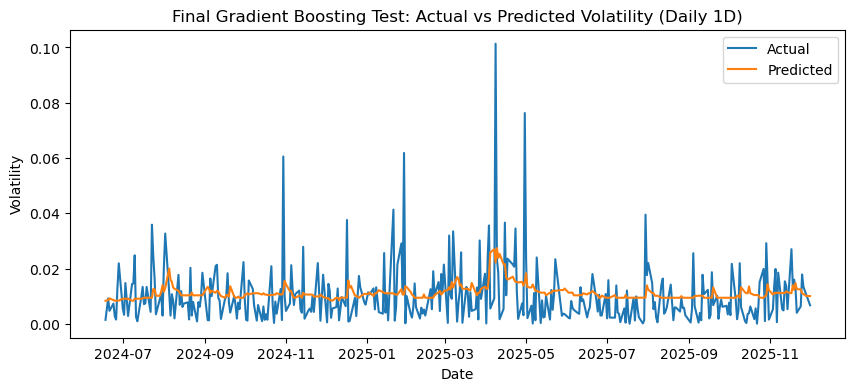

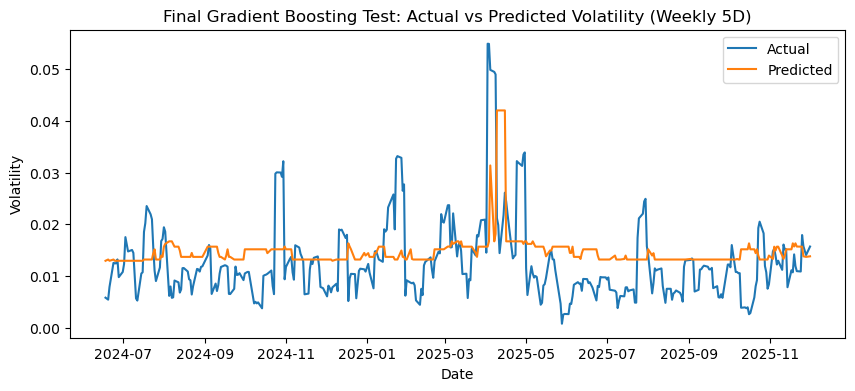

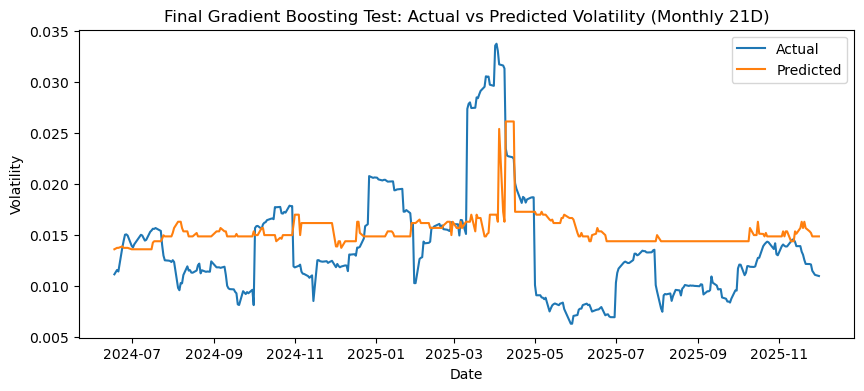

In [29]:

# Final Test Evaluation using Best Validation Parameters
from IPython.display import display

# Horizon order
horizon_order = ['Daily 1D', 'Weekly 5D', 'Monthly 21D']

targets_full = {
    'Daily 1D': (y_train_1d, y_valid_1d, y_test_1d),
    'Weekly 5D': (y_train_5d, y_valid_5d, y_test_5d),
    'Monthly 21D': (y_train_21d, y_valid_21d, y_test_21d)
}

# Combine train + validation features
X_train_valid = pd.concat([X_train, X_valid])

final_scaler = StandardScaler()

X_train_valid_scaled = final_scaler.fit_transform(X_train_valid)
X_test_scaled_final = final_scaler.transform(X_test)

X_train_valid_scaled = pd.DataFrame(
    X_train_valid_scaled,
    index=X_train_valid.index,
    columns=feature_cols
)

X_test_scaled_final = pd.DataFrame(
    X_test_scaled_final,
    index=X_test.index,
    columns=feature_cols
)


# Final model training and test evaluation
final_test_results = []
final_gb_models = {}
final_gb_test_predictions = {}

for _, row in best_params_by_horizon.iterrows():
    
    horizon = row['Horizon']
    
    y_train, y_valid, y_test = targets_full[horizon]
    
    y_train_valid = pd.concat([y_train, y_valid])
    
    final_model = GradientBoostingRegressor(
        n_estimators=int(row['n_estimators']),
        learning_rate=float(row['learning_rate']),
        max_depth=int(row['max_depth']),
        random_state=42
    )
    
    final_model.fit(X_train_valid_scaled, y_train_valid)
    
    # Predict on test set only
    y_test_pred = final_model.predict(X_test_scaled_final)
    
    # Test metrics
    test_mae = mean_absolute_error(y_test, y_test_pred)
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    test_r2 = r2_score(y_test, y_test_pred)
    test_normalized_mae = test_mae / y_test.mean()
    
    final_test_results.append({
        'Horizon': horizon,
        'n_estimators': int(row['n_estimators']),
        'learning_rate': float(row['learning_rate']),
        'max_depth': int(row['max_depth']),
        'Test MAE': test_mae,
        'Test RMSE': test_rmse,
        'Test Normalized MAE': test_normalized_mae,
        'Test R2': test_r2
    })
    
    final_gb_models[horizon] = final_model
    final_gb_test_predictions[horizon] = y_test_pred


# Create final test results DataFrame
final_test_results_df = pd.DataFrame(final_test_results)

final_test_results_df['Horizon'] = pd.Categorical(
    final_test_results_df['Horizon'],
    categories=horizon_order,
    ordered=True
)

final_test_results_df = (
    final_test_results_df
    .sort_values('Horizon')
    .reset_index(drop=True)
)

print("Final Gradient Boosting Test Performance:")
display(final_test_results_df)


# Test Actual vs Predicted Plots
for horizon in horizon_order:
    
    _, _, y_test = targets_full[horizon]
    y_test_pred = final_gb_test_predictions[horizon]
    
    plt.figure(figsize=(10, 4))
    plt.plot(y_test.index, y_test, label='Actual')
    plt.plot(y_test.index, y_test_pred, label='Predicted')
    plt.title(f'Final Gradient Boosting Test: Actual vs Predicted Volatility ({horizon})')
    plt.xlabel('Date')
    plt.ylabel('Volatility')
    plt.legend()
    plt.show()

## 4.4 Model 3: ___

**Implemented by: Shawn Wen** 

- Motivation
- Model description
- Why this method is appropriate


Repeat until Model N (N=your group size)


## 4.5 Model 4: Random Forest

**Implemented by: Zihan Zhu** 

- Motivation

Random Forest is chosen because future stock volatility may depend on complex interactions among market variables. Features such as VIX, SPY returns, QQQ returns, trading volume, lagged MSFT returns, and rolling volatility may influence future volatility in a nonlinear way. A simple linear model may not fully capture these relationships.

Random Forest is also robust to noisy financial data. By averaging predictions from many decision trees, it can reduce overfitting and improve prediction stability compared with a single decision tree.

- Model description

Random Forest is an ensemble learning method based on bagging. The model builds many decision trees using bootstrap samples of the training data. At each split, only a random subset of features is considered, which increases diversity among trees.

For a regression problem, the final prediction is the average prediction across all trees in the forest. In this project, we tune the main hyperparameters including the number of trees (n_estimators), maximum tree depth (max_depth), and minimum number of samples required in a leaf node (min_samples_leaf). The best parameter combination is selected using validation RMSE.

- Why this method is appropriate

Random Forest is appropriate because stock volatility often exhibits nonlinear behavior and interactions among market indicators. It can capture these patterns without requiring us to manually specify nonlinear terms or interaction effects.

The main assumption is that historical market information contains useful signals for future volatility prediction. We also split the data chronologically into training, validation, and test sets to avoid look-ahead bias. Since Random Forest is tree-based, feature scaling is not required, making it relatively robust to differences in feature magnitude.

Repeat until Model N (N=your group size)


In [ ]:
# =========================
# Random Forest Hyperparameter Tuning
# =========================

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import numpy as np
import pandas as pd

horizon_order = ['Daily 1D', 'Weekly 5D', 'Monthly 21D']

targets = {
    'Daily 1D': (y_train_1d, y_valid_1d, y_test_1d),
    'Weekly 5D': (y_train_5d, y_valid_5d, y_test_5d),
    'Monthly 21D': (y_train_21d, y_valid_21d, y_test_21d)
}

param_grid = []

# -------------------------
# Round 1: Initial Search
# -------------------------

for n_estimators in [100, 200]:
    for max_depth in [3, 5, 8]:
        for min_samples_leaf in [3, 5, 10]:

            param_grid.append({
                'Search Round': 'Initial Search',
                'n_estimators': n_estimators,
                'max_depth': max_depth,
                'min_samples_leaf': min_samples_leaf
            })

# -------------------------
# Round 2: Refined Search
# -------------------------

for max_depth in [2, 3, 4, 5, 6]:
    for min_samples_leaf in [8, 10, 12]:

        param_grid.append({
            'Search Round': 'Refined Search',
            'n_estimators': 200,
            'max_depth': max_depth,
            'min_samples_leaf': min_samples_leaf
        })

rf_tuning_results = []

for horizon in horizon_order:

    y_train, y_valid, y_test = targets[horizon]

    for params in param_grid:

        model = RandomForestRegressor(
            n_estimators=params['n_estimators'],
            max_depth=params['max_depth'],
            min_samples_leaf=params['min_samples_leaf'],
            random_state=42,
            n_jobs=-1
        )

        model.fit(X_train_scaled, y_train)

        y_valid_pred = model.predict(X_valid_scaled)

        valid_mae = mean_absolute_error(
            y_valid,
            y_valid_pred
        )

        valid_rmse = np.sqrt(
            mean_squared_error(
                y_valid,
                y_valid_pred
            )
        )

        valid_r2 = r2_score(
            y_valid,
            y_valid_pred
        )

        rf_tuning_results.append({
            'Search Round': params['Search Round'],
            'Horizon': horizon,
            'n_estimators': params['n_estimators'],
            'max_depth': params['max_depth'],
            'min_samples_leaf': params['min_samples_leaf'],
            'Validation MAE': valid_mae,
            'Validation RMSE': valid_rmse,
            'Validation R2': valid_r2
        })

rf_tuning_results = pd.DataFrame(
    rf_tuning_results
)

rf_tuning_results.head()

In [ ]:
# =========================
# Best Hyperparameters
# =========================

best_rf_params = (
    rf_tuning_results
    .sort_values('Validation RMSE')
    .groupby('Horizon')
    .head(1)
    .reset_index(drop=True)
)

best_rf_params

In [ ]:
# =========================
# Final Test Evaluation
# =========================

rf_test_results = []

rf_models = {}

rf_test_predictions = {}

X_train_valid_scaled = np.vstack([
    np.asarray(X_train_scaled),
    np.asarray(X_valid_scaled)
])

X_test_scaled_array = np.asarray(
    X_test_scaled
)

for _, row in best_rf_params.iterrows():

    horizon = row['Horizon']

    y_train, y_valid, y_test = targets[horizon]

    y_train_valid = pd.concat([
        y_train,
        y_valid
    ])

    final_rf = RandomForestRegressor(
        n_estimators=int(row['n_estimators']),
        max_depth=int(row['max_depth']),
        min_samples_leaf=int(row['min_samples_leaf']),
        random_state=42,
        n_jobs=-1
    )

    final_rf.fit(
        X_train_valid_scaled,
        y_train_valid
    )

    y_test_pred = final_rf.predict(
        X_test_scaled_array
    )

    test_mae = mean_absolute_error(
        y_test,
        y_test_pred
    )

    test_rmse = np.sqrt(
        mean_squared_error(
            y_test,
            y_test_pred
        )
    )

    test_r2 = r2_score(
        y_test,
        y_test_pred
    )

    baseline_pred = np.repeat(
        y_train_valid.mean(),
        len(y_test)
    )

    baseline_rmse = np.sqrt(
        mean_squared_error(
            y_test,
            baseline_pred
        )
    )

    improvement = (
        baseline_rmse -
        test_rmse
    ) / baseline_rmse

    rf_test_results.append({
        'Horizon': horizon,
        'Search Round': row['Search Round'],
        'Best n_estimators': int(row['n_estimators']),
        'Best max_depth': int(row['max_depth']),
        'Best min_samples_leaf': int(row['min_samples_leaf']),
        'Test MAE': test_mae,
        'Test RMSE': test_rmse,
        'Test R2': test_r2,
        'Baseline RMSE': baseline_rmse,
        'Improvement over Baseline': improvement
    })

    rf_models[horizon] = final_rf

    rf_test_predictions[horizon] = y_test_pred

rf_summary = pd.DataFrame(
    rf_test_results
)

rf_summary.round(4)

In [ ]:
# =========================
# Deep Tree Check
# =========================

deep_check_grid = [
    {'n_estimators': 100, 'max_depth': 8, 'min_samples_leaf': 10},
    {'n_estimators': 100, 'max_depth': 10, 'min_samples_leaf': 10},
    {'n_estimators': 100, 'max_depth': 12, 'min_samples_leaf': 10},
]

deep_check_results = []

for horizon in horizon_order:

    y_train, y_valid, y_test = targets[horizon]

    for params in deep_check_grid:

        model = RandomForestRegressor(
            n_estimators=params['n_estimators'],
            max_depth=params['max_depth'],
            min_samples_leaf=params['min_samples_leaf'],
            random_state=42,
            n_jobs=-1
        )

        model.fit(X_train_scaled, y_train)

        y_valid_pred = model.predict(X_valid_scaled)

        valid_mae = mean_absolute_error(y_valid, y_valid_pred)
        valid_rmse = np.sqrt(mean_squared_error(y_valid, y_valid_pred))
        valid_r2 = r2_score(y_valid, y_valid_pred)

        deep_check_results.append({
            'Horizon': horizon,
            'n_estimators': params['n_estimators'],
            'max_depth': params['max_depth'],
            'min_samples_leaf': params['min_samples_leaf'],
            'Validation MAE': valid_mae,
            'Validation RMSE': valid_rmse,
            'Validation R2': valid_r2
        })

deep_check_results = pd.DataFrame(deep_check_results)

deep_check_results.sort_values(
    ['Horizon', 'Validation RMSE']
)

In [ ]:
# =========================
# Feature Importance Tables
# =========================

for horizon in horizon_order:

    model = rf_models[horizon]

    importance = pd.DataFrame({
        'Feature': feature_cols,
        'Importance': model.feature_importances_
    })

    importance = (
        importance
        .sort_values(
            'Importance',
            ascending=False
        )
    )

    print("\n")
    print("=" * 60)
    print(horizon)
    print("=" * 60)

    display(
        importance.head(15)
    )

In [ ]:
# =========================
# Feature Importance Plot
# =========================

for horizon in horizon_order:

    model = rf_models[horizon]

    importance = pd.DataFrame({
        'Feature': feature_cols,
        'Importance': model.feature_importances_
    })

    importance = (
        importance
        .sort_values(
            'Importance',
            ascending=False
        )
        .head(15)
    )

    plt.figure(figsize=(10,6))

    plt.barh(
        importance['Feature'],
        importance['Importance']
    )

    plt.gca().invert_yaxis()

    plt.title(
        f'Random Forest Feature Importance ({horizon})'
    )

    plt.xlabel('Importance')

    plt.show()

In [ ]:
# =========================
# Actual vs Predicted
# =========================

for horizon in horizon_order:

    y_train, y_valid, y_test = targets[horizon]

    y_test_pred = rf_test_predictions[horizon]

    plt.figure(figsize=(14,5))

    plt.plot(
        y_test.index,
        y_test.values,
        label='Actual'
    )

    plt.plot(
        y_test.index,
        y_test_pred,
        label='Predicted'
    )

    plt.title(
        f'Random Forest: Actual vs Predicted ({horizon})'
    )

    plt.xlabel('Date')
    plt.ylabel('Volatility')

    plt.xticks(rotation=45)

    plt.legend()

    plt.tight_layout()

    plt.show()

In [ ]:
# =========================
# Residual Plot
# =========================

for horizon in horizon_order:

    y_train, y_valid, y_test = targets[horizon]

    y_test_pred = rf_test_predictions[horizon]

    residuals = (
        y_test -
        y_test_pred
    )

    plt.figure(figsize=(6,5))

    plt.scatter(
        y_test_pred,
        residuals,
        alpha=0.5
    )

    plt.axhline(
        y=0,
        linestyle='--'
    )

    plt.xlabel('Predicted')

    plt.ylabel('Residual')

    plt.title(
        f'Residual Plot ({horizon})'
    )

    plt.show()

In [ ]:
# Compare current best RF parameters with deep tree check

current_best = best_rf_params[
    [
        'Horizon',
        'Search Round',
        'n_estimators',
        'max_depth',
        'min_samples_leaf',
        'Validation RMSE',
        'Validation R2'
    ]
].copy()

current_best['Model Type'] = 'Selected Shallow RF'

deep_best = (
    deep_check_results
    .sort_values('Validation RMSE')
    .groupby('Horizon')
    .head(1)
    .reset_index(drop=True)
)

deep_best['Search Round'] = 'Deep Tree Check'
deep_best['Model Type'] = 'Deep RF'

comparison = pd.concat([
    current_best,
    deep_best[
        [
            'Horizon',
            'Search Round',
            'n_estimators',
            'max_depth',
            'min_samples_leaf',
            'Validation RMSE',
            'Validation R2',
            'Model Type'
        ]
    ]
])

comparison.sort_values(
    ['Horizon', 'Validation RMSE']
)

# 5. Results

Clearly separate the presentation of results from the conclusions.

## 5.1 Evaluation Metrics
- Explain why the chosen metrics are appropriate.

## 5.2 Main Quantitative Results
- Present results in tables. Compare model performance after tuning.


## 5.3 Visualizations
- Prediction vs actual
- Residual plots
- Feature importance
- Confusion matrix or ROC curve if classification


# 6. Discussions and Conclusions

Make it brief; (2-3 paragraphs max)

Discuss:
- Which model performed best?
- Why do you think it performed best?
- What do the results mean in the financial context?
- Are there economic or practical implications?
- What are the limitations of the study?

Conclude:
- Summarize the main findings.
- State the major takeaway.
- Suggest possible future work.

# Appendix. Reproducibility

- State the software environment.
- State package versions if relevant.
- Explain how to reproduce the analysis.
- Ensure the notebook has been run from start to finish.


In [10]:
# example: package versions
# import sys
# print(sys.version)
# print(pd.__version__)
# print(np.__version__)

# References

- Include all papers, datasets, websites, and software packages cited in the notebook.
- Use a consistent citation style.
